In [12]:
import os
import torch

SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

ckpt = torch.load(MODEL_PATH, map_location="cpu")

print(type(ckpt))
print("Number of keys:", len(ckpt))

for i, k in enumerate(ckpt.keys()):
    print(i, k, ckpt[k].shape if hasattr(ckpt[k], "shape") else type(ckpt[k]))

<class 'collections.OrderedDict'>
Number of keys: 19
0 nodes.0.callable.linear.0.weight torch.Size([60, 1])
1 nodes.0.callable.linear.0.bias torch.Size([60])
2 nodes.0.callable.linear.1.weight torch.Size([60, 60])
3 nodes.0.callable.linear.1.bias torch.Size([60])
4 nodes.0.callable.linear.2.weight torch.Size([60, 60])
5 nodes.0.callable.linear.2.bias torch.Size([60])
6 nodes.0.callable.linear.3.weight torch.Size([10, 60])
7 nodes.0.callable.linear.3.bias torch.Size([10])
8 nodes.1.callable.linear.0.weight torch.Size([60, 1])
9 nodes.1.callable.linear.0.bias torch.Size([60])
10 nodes.1.callable.linear.1.weight torch.Size([60, 60])
11 nodes.1.callable.linear.1.bias torch.Size([60])
12 nodes.1.callable.linear.2.weight torch.Size([60, 60])
13 nodes.1.callable.linear.2.bias torch.Size([60])
14 nodes.1.callable.linear.3.weight torch.Size([10, 60])
15 nodes.1.callable.linear.3.bias torch.Size([10])
16 nodes.2.callable.weight torch.Size([10, 1])
17 nodes.3.nodes.0.callable.K.weight torch.Size(

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
D_koop shape: (1, 1)
Decoded y from true encoder x(59): 58.946653551995
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


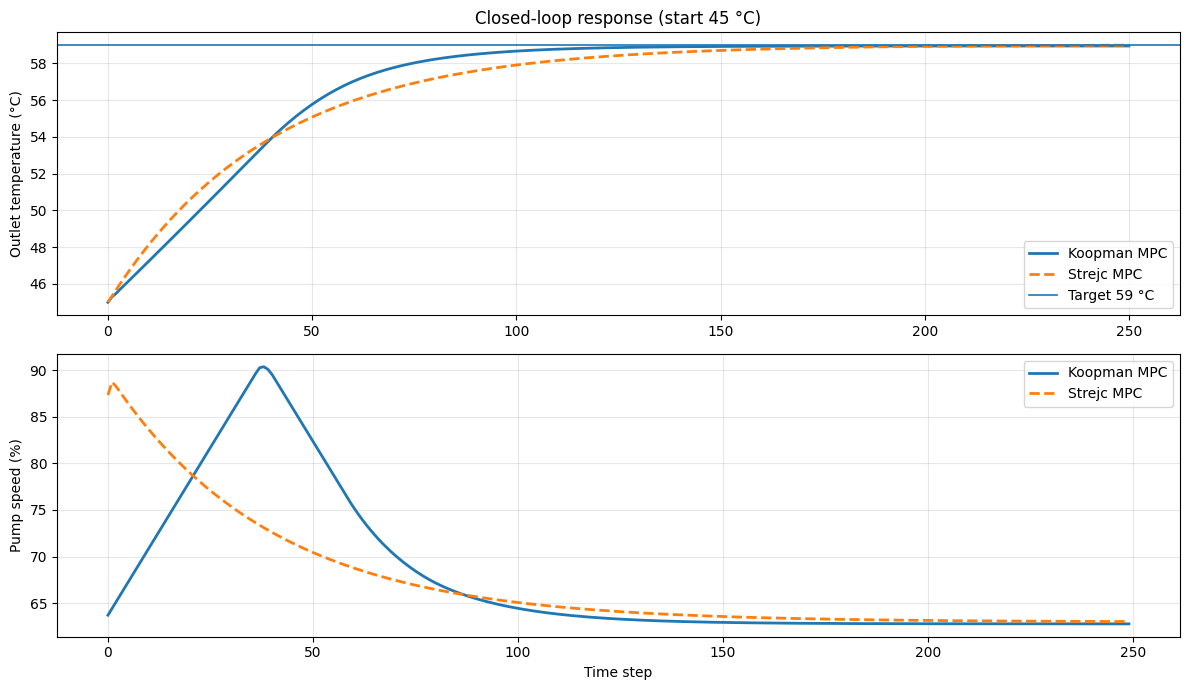

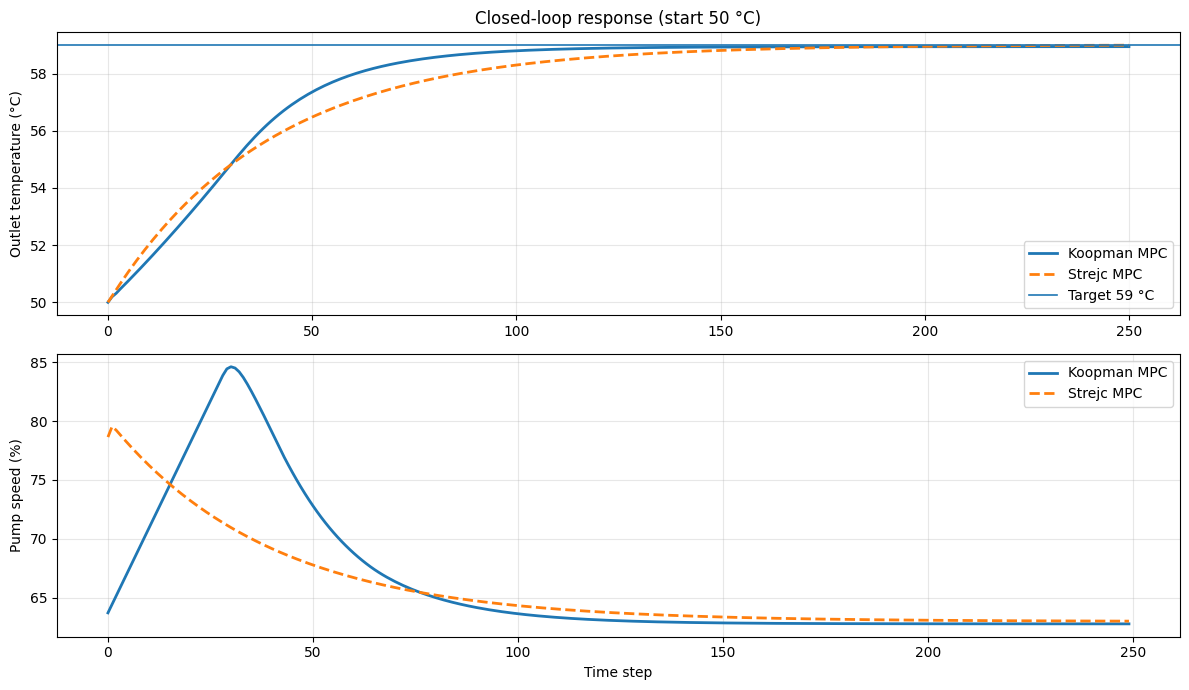

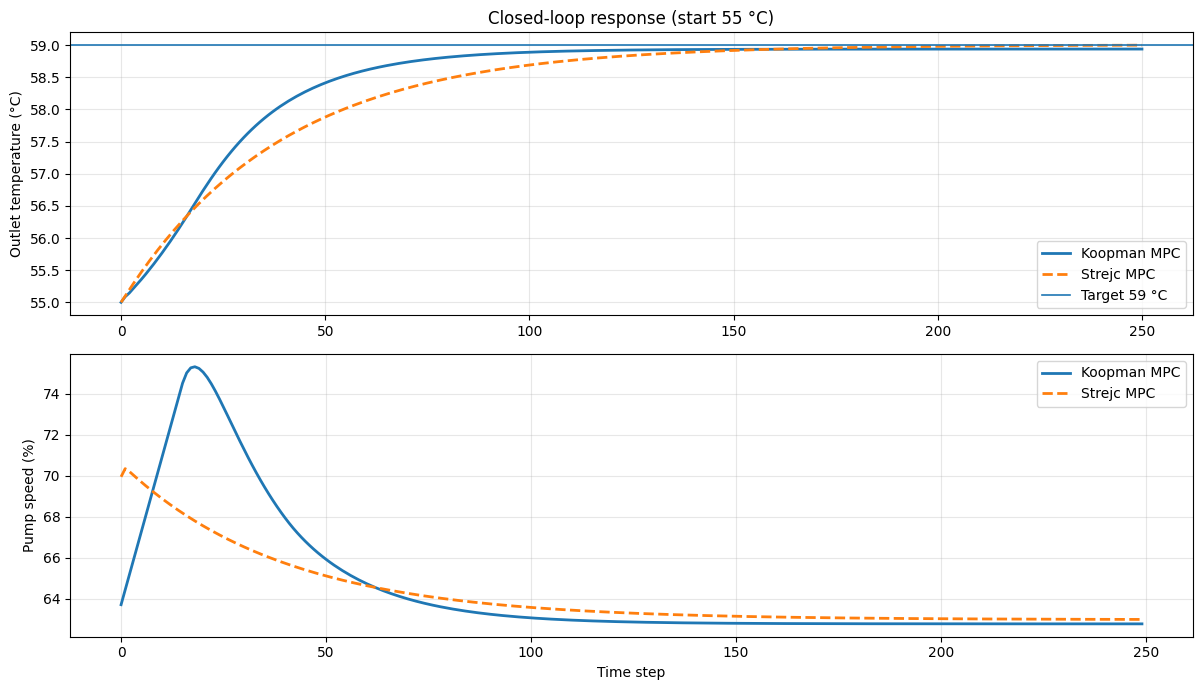

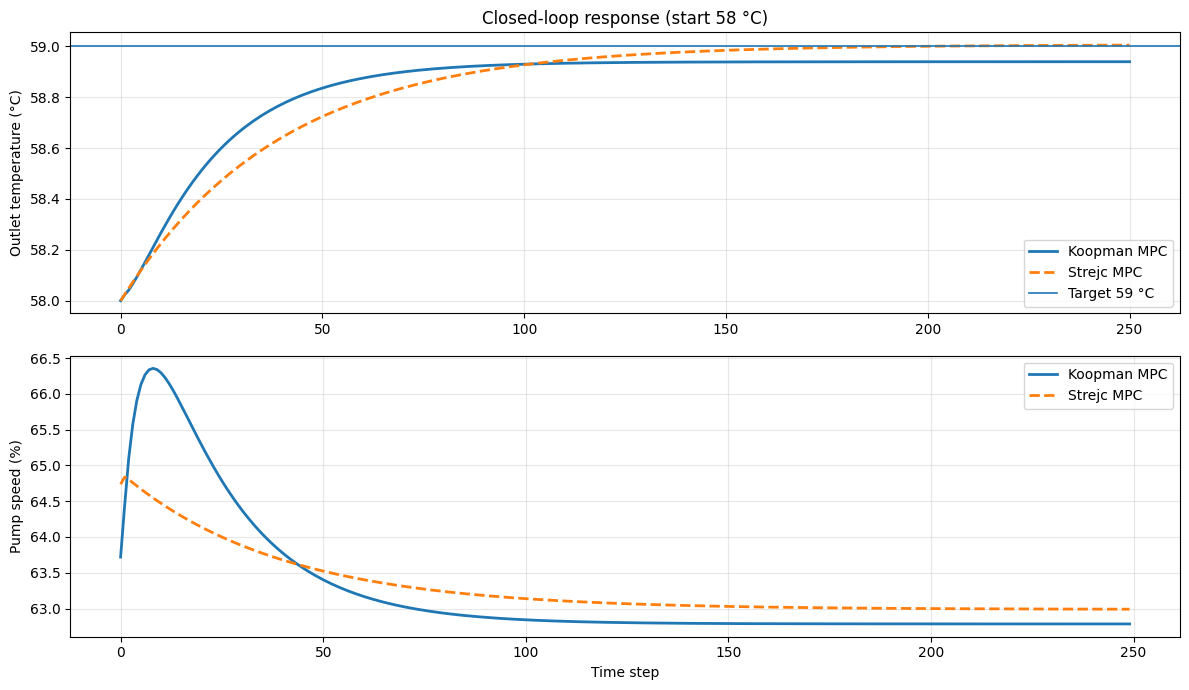

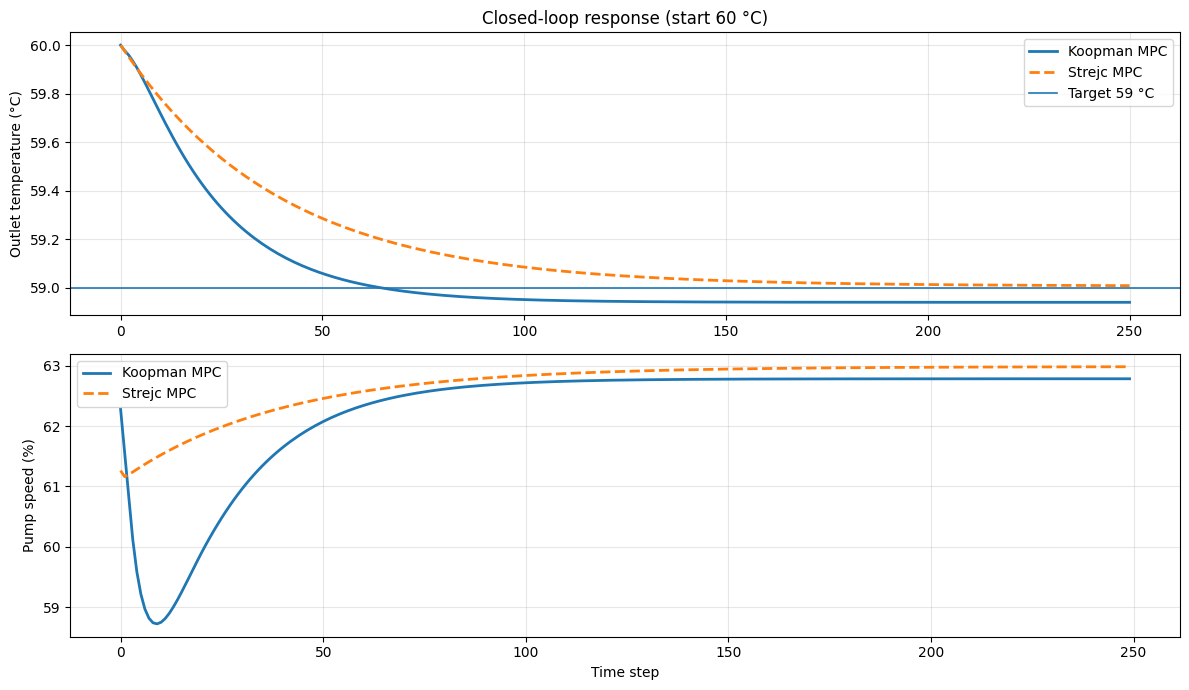

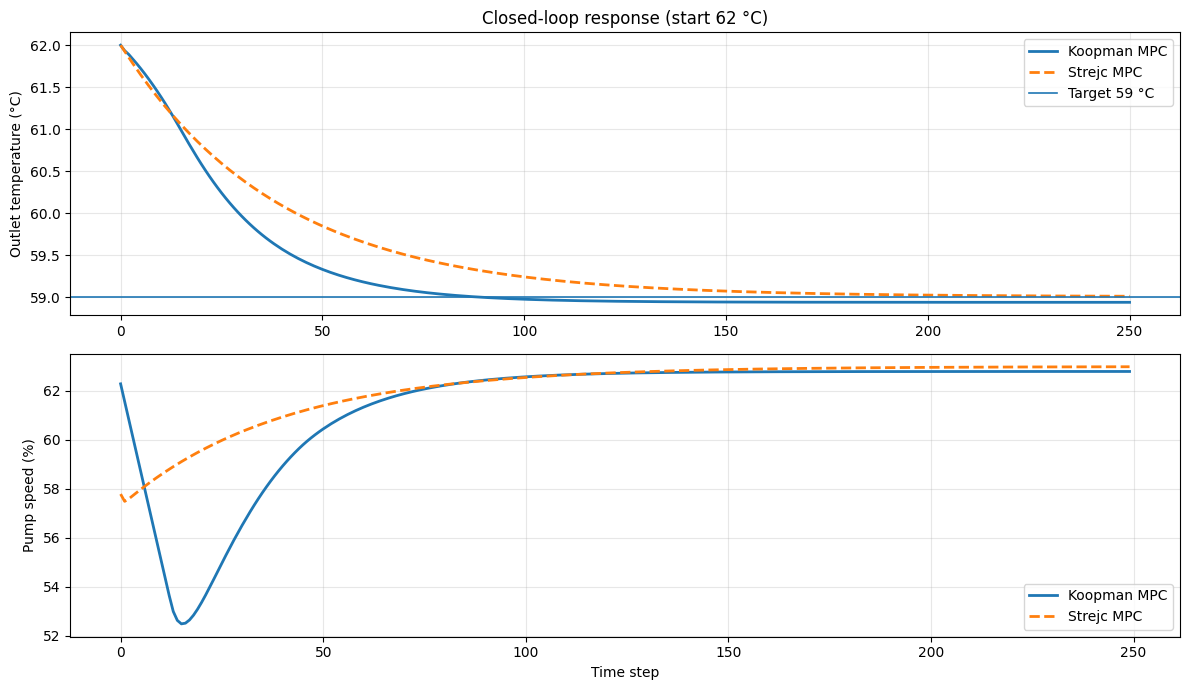

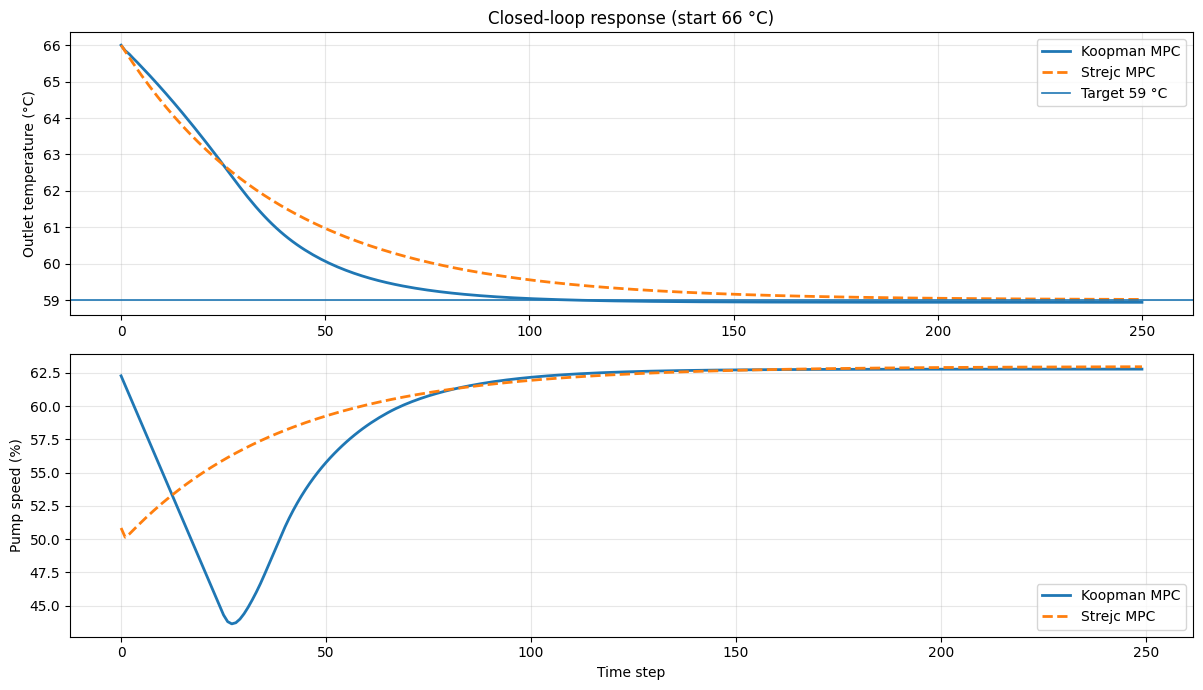

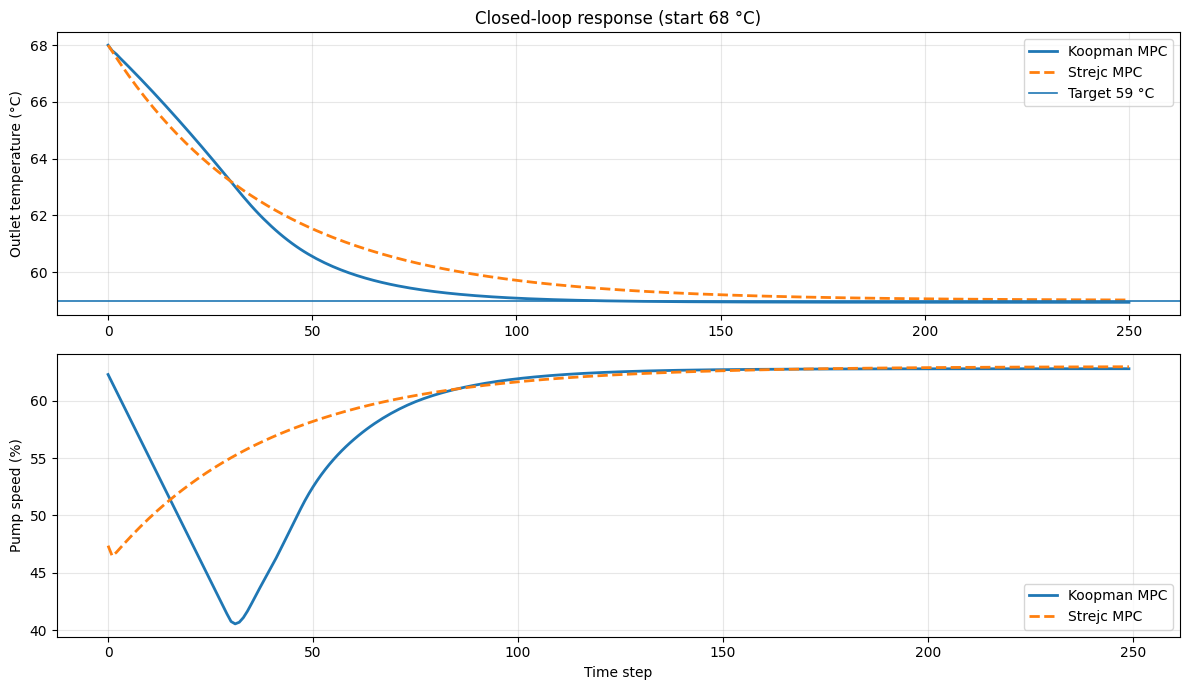

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  4.140048  3.979595  506.619014  555.989889  63768.726116  53700.513271
1  50  2.550173  2.557677  304.551324  356.938884  27706.163895  22181.541301
2  55  1.049633  1.135763  126.263115  157.887879   5937.169976   4373.964293
3  58  0.251330  0.282649   38.248991   38.742904    375.259683    270.887671
4  60  0.232743  0.286219   31.240041   41.163126    523.673600    277.782248
5  62  0.757446  0.854954   85.970149  120.783527   3765.837024   2478.500019
6  66  1.925903  1.992481  218.860950  280.024331  18054.613929  13461.405143
7  68  2.542995  2.561248  293.533987  359.644733  28621.134246  22243.592496

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
DATA_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\ws2025\data"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0
Qdu_strejc = 0.1

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qu_koop = 1.0
Qdu_koop = 20.0
u_step_max_scaled = 0.03

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

# requested lower bound
ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

# load encoder weights from nodes.0 (encoder_Y0)
with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)
D_koop = np.zeros((1, 1), dtype=float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)
print("D_koop shape:", D_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# sanity check
x59 = encode_y_to_x(59.0)
print("Decoded y from true encoder x(59):", decode_x_to_y_phys(x59))

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(
    A, B, C, x0, yref, N=20, Qy=10.0, Qu=0.1, Qdu=0.1,
    dumin=None, dumax=None, du_prev=0.0
):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(
    A, B, C, x0, yref_scaled, u_prev_scaled,
    N=20, Qy=10.0, Qu=1.0, Qdu=20.0,
    umin_scaled=None, umax_scaled=None, u_step_max=0.03,
    ymin_scaled=None
):
    """
    Koopman MPC in scaled coordinates:
        x+ = A x + B u_scaled
        y_scaled = C x
    optimization variable = ABSOLUTE scaled input
    """
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - u_prev_scaled)
            constraints += [U[:, [k]] - u_prev_scaled <= u_step_max]
            constraints += [U[:, [k]] - u_prev_scaled >= -u_step_max]
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])
            constraints += [U[:, [k]] - U[:, [k-1]] <= u_step_max]
            constraints += [U[:, [k]] - U[:, [k-1]] >= -u_step_max]

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    u_prev_scaled = u_phys_to_scaled(u_ss)

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]

        # TRUE encoder-based latent state
        x0_k = encode_y_to_x(y_now_phys)

        # solve Koopman MPC on absolute scaled input
        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            yref_scaled=y_target_scaled,
            u_prev_scaled=u_prev_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qu=Qu_koop,
            Qdu=Qdu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            u_step_max=u_step_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

        u_prev_scaled = u_k_scaled

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []
    du_prev_s = 0.0

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            Qdu=Qdu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys,
            du_prev=du_prev_s
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

        du_prev_s = du_s

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(encode_y_to_x(y_target)))

In [3]:
import numpy as np
import os

DATA_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\ws2025\data"

files = sorted(os.listdir(DATA_DIR))
for f in files:
    print(f)

print("\nTrying A matrix:")
A = np.load(os.path.join(DATA_DIR, "A_wC_all.npy"))
print("A shape:", A.shape)
print(A[:5, :5])

A_wC_all.npy
B_wC_all.npy
C_wC_all.npy
D_wC_all.npy
model_baseline.pth
test_data_ident.mat
train_data_ident.mat

Trying A matrix:
A shape: (10, 10)
[[-0.07792052 -0.2451889   0.22119622  0.04804968 -0.05841755]
 [-0.00207151  0.29012346 -0.03023512  0.16018903 -0.10515956]
 [-0.35088938 -0.23109584 -0.27864814  0.04266162  0.3513113 ]
 [ 0.09374531 -0.20237964  0.14501056  0.02976744  0.02321582]
 [ 0.02294573 -0.2158864   0.05845194  0.4077477   0.19659355]]


scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
D_koop shape: (1, 1)
Decoded y from true encoder x(target): 58.946653551995
Model-consistent target scaled: 0.08553528232462011
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


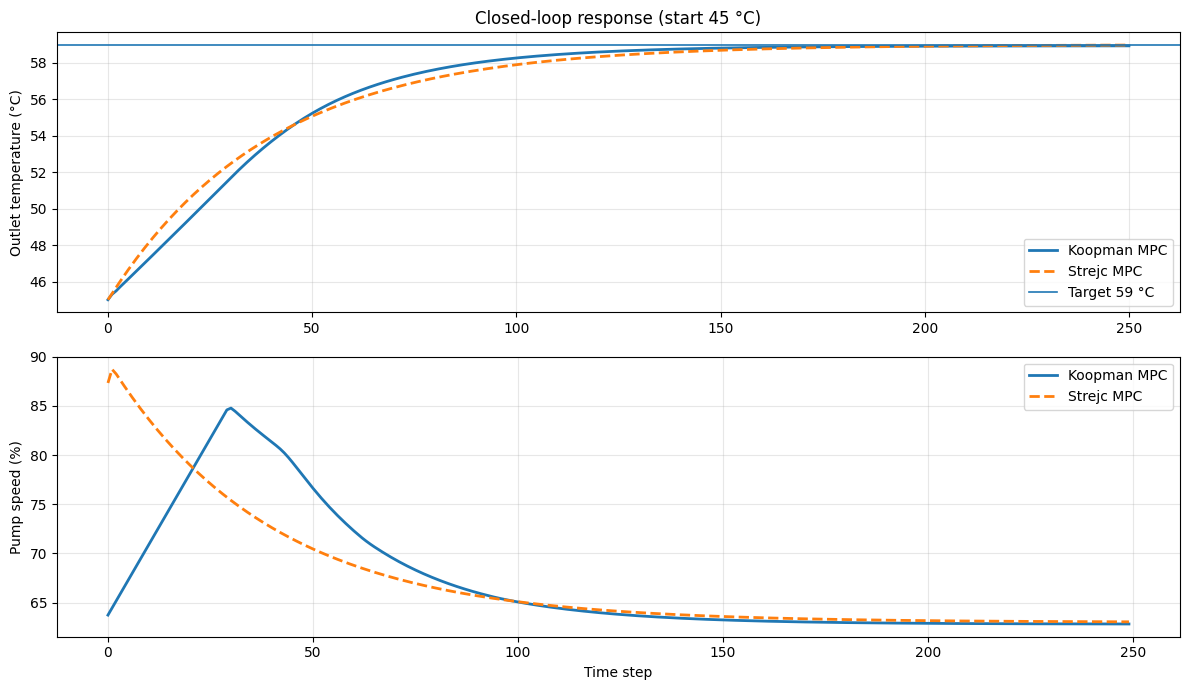

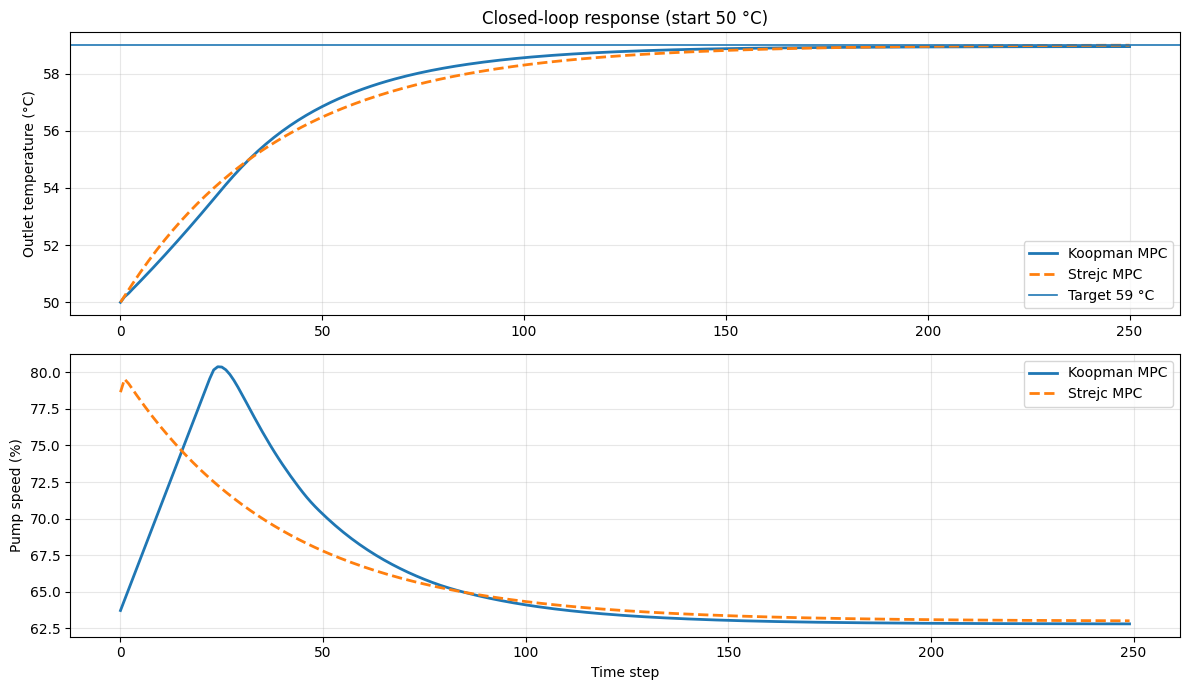

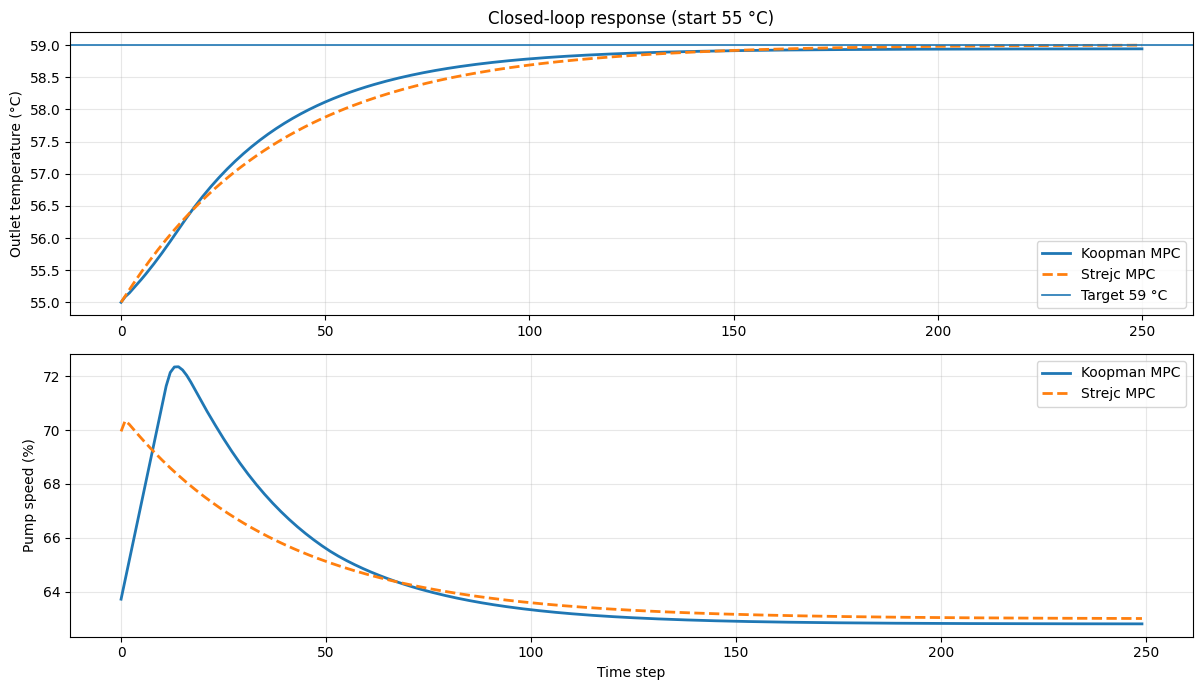

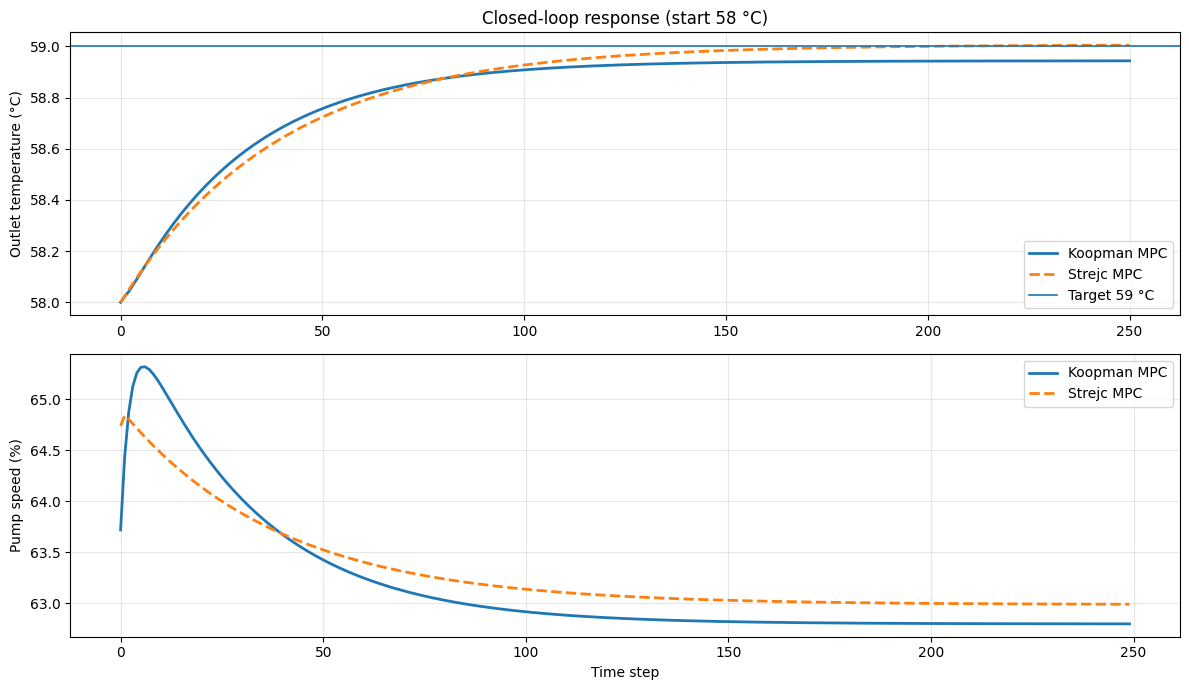

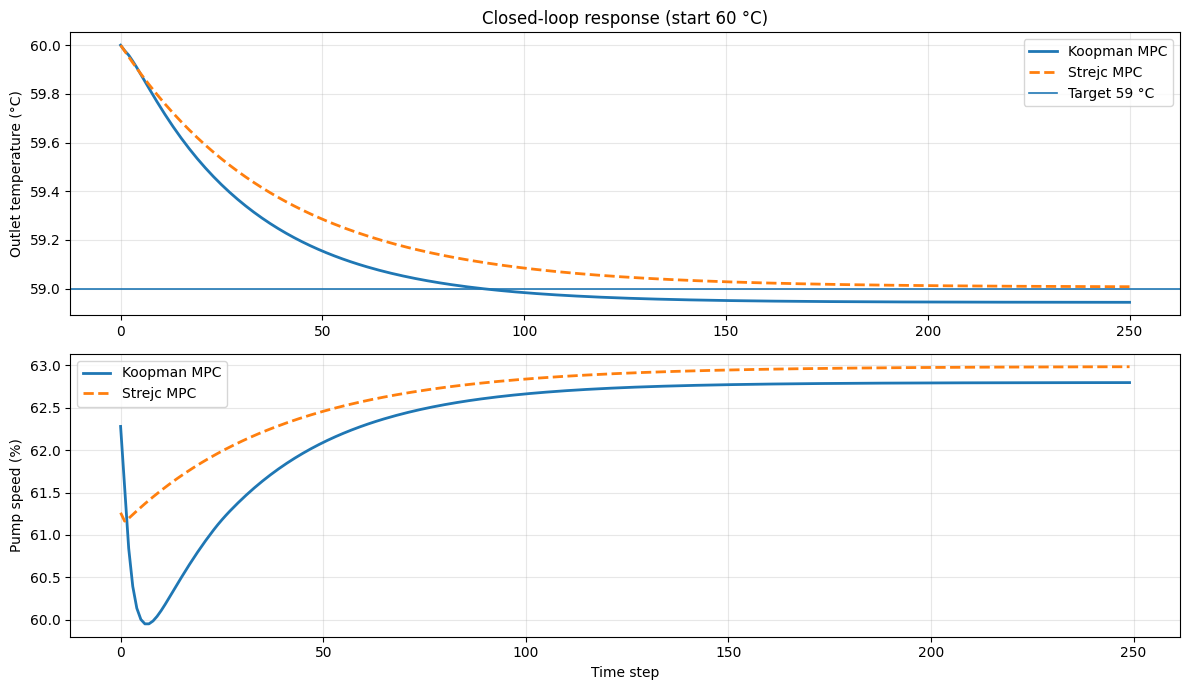

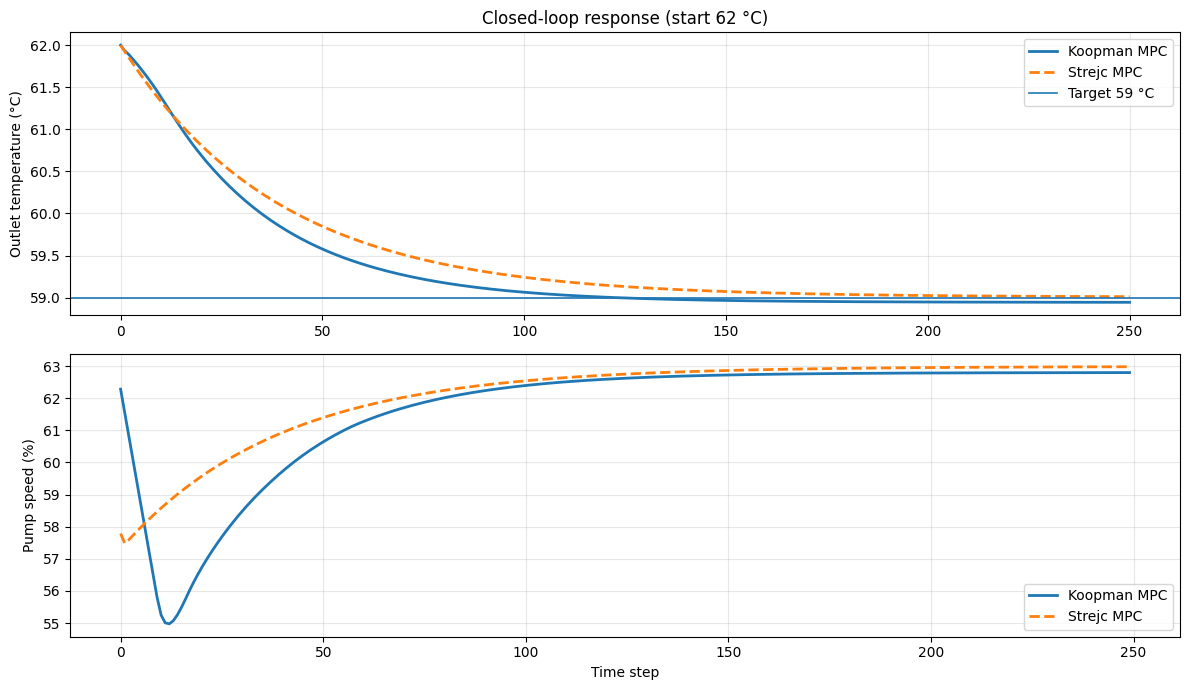

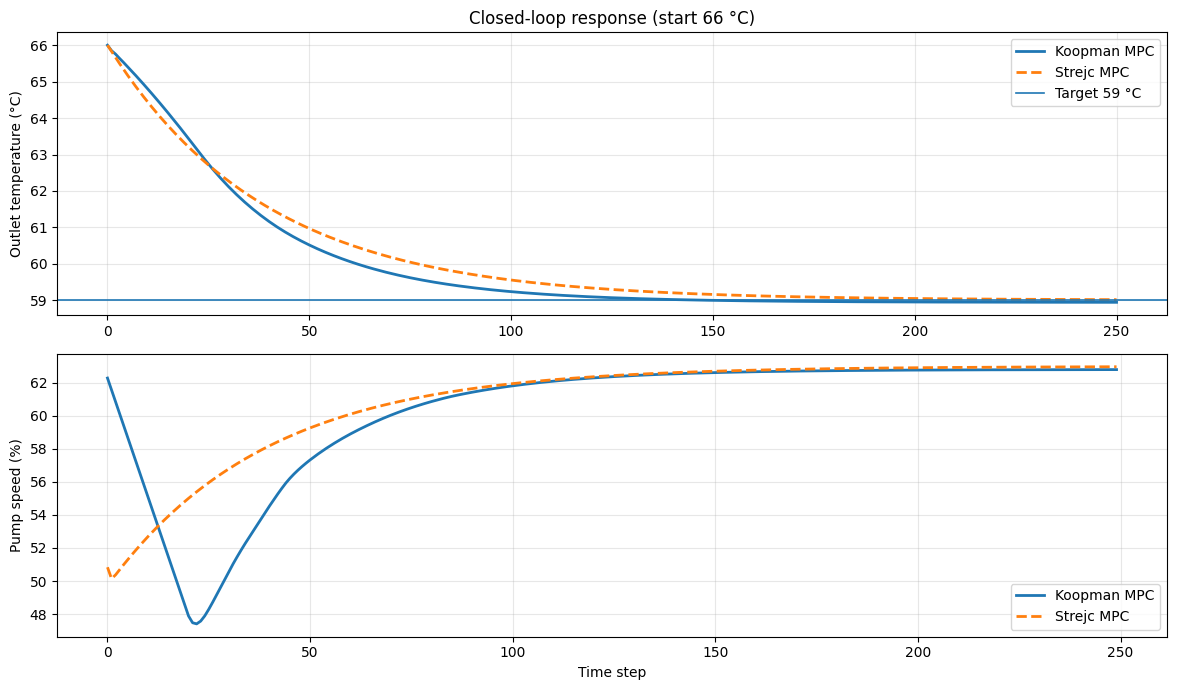

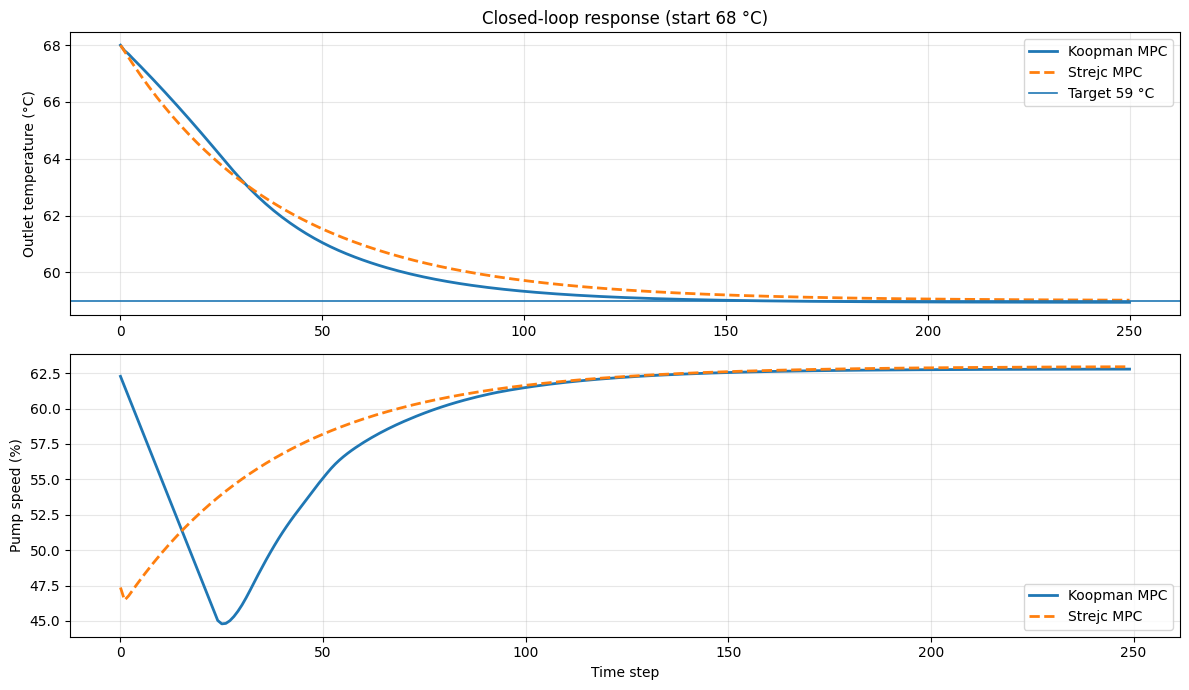

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  4.208276  3.979595  553.860026  555.989889  58493.620641  53700.513271
1  50  2.611299  2.557677  339.829609  356.938884  24623.228736  22181.541301
2  55  1.103370  1.135763  147.004832  157.887879   4920.040063   4373.964293
3  58  0.275658  0.282649   44.037826   38.742904    298.853438    270.887671
4  60  0.251920  0.286219   34.355650   41.163126    381.694760    277.782248
5  62  0.799071  0.854954   98.764175  120.783527   2991.411801   2478.500019
6  66  1.977920  1.992481  244.339007  280.024331  15554.446789  13461.405143
7  68  2.595457  2.561248  323.243110  359.644733  25344.446267  22243.592496

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
y_ref_model_scaled = 0.08553528232462011
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [14]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0
Qdu_strejc = 0.1

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qx_koop = 1.0
QxN_koop = 20.0
Qu_koop = 1.0
Qdu_koop = 20.0
u_step_max_scaled = 0.03

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

# requested lower bound
ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)
D_koop = np.zeros((1, 1), dtype=float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)
print("D_koop shape:", D_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# model-consistent target
x_ref = encode_y_to_x(y_target)
y_ref_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_model_phys = decode_x_to_y_phys(x_ref)

print("Decoded y from true encoder x(target):", y_ref_model_phys)
print("Model-consistent target scaled:", y_ref_model_scaled)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(
    A, B, C, x0, yref, N=20, Qy=10.0, Qu=0.1, Qdu=0.1,
    dumin=None, dumax=None, du_prev=0.0
):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - du_prev)
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(du_prev)
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(
    A, B, C, x0, xref, yref_scaled, u_prev_scaled,
    N=20, Qy=10.0, Qx=1.0, QxN=10.0, Qu=1.0, Qdu=20.0,
    umin_scaled=None, umax_scaled=None, u_step_max=0.03,
    ymin_scaled=None
):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    yref_scaled = float(yref_scaled)
    xref = xref.reshape(-1, 1)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qx * cp.sum_squares(X[:, [k]] - xref)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if k == 0:
            objective += Qdu * cp.sum_squares(U[:, [k]] - u_prev_scaled)
            constraints += [U[:, [k]] - u_prev_scaled <= u_step_max]
            constraints += [U[:, [k]] - u_prev_scaled >= -u_step_max]
        else:
            objective += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])
            constraints += [U[:, [k]] - U[:, [k-1]] <= u_step_max]
            constraints += [U[:, [k]] - U[:, [k-1]] >= -u_step_max]

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    objective += QxN * cp.sum_squares(X[:, [N]] - xref)

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    u_prev_scaled = u_phys_to_scaled(u_ss)

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]

        # encoder-based current latent state
        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            xref=x_ref,
            yref_scaled=y_ref_model_scaled,
            u_prev_scaled=u_prev_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qx=Qx_koop,
            QxN=QxN_koop,
            Qu=Qu_koop,
            Qdu=Qdu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            u_step_max=u_step_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

        u_prev_scaled = u_k_scaled

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []
    du_prev_s = 0.0

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            Qdu=Qdu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys,
            du_prev=du_prev_s
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

        du_prev_s = du_s

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_model_scaled =", y_ref_model_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
D_koop shape: (1, 1)
Decoded y from true encoder x(59): 58.946653551995
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


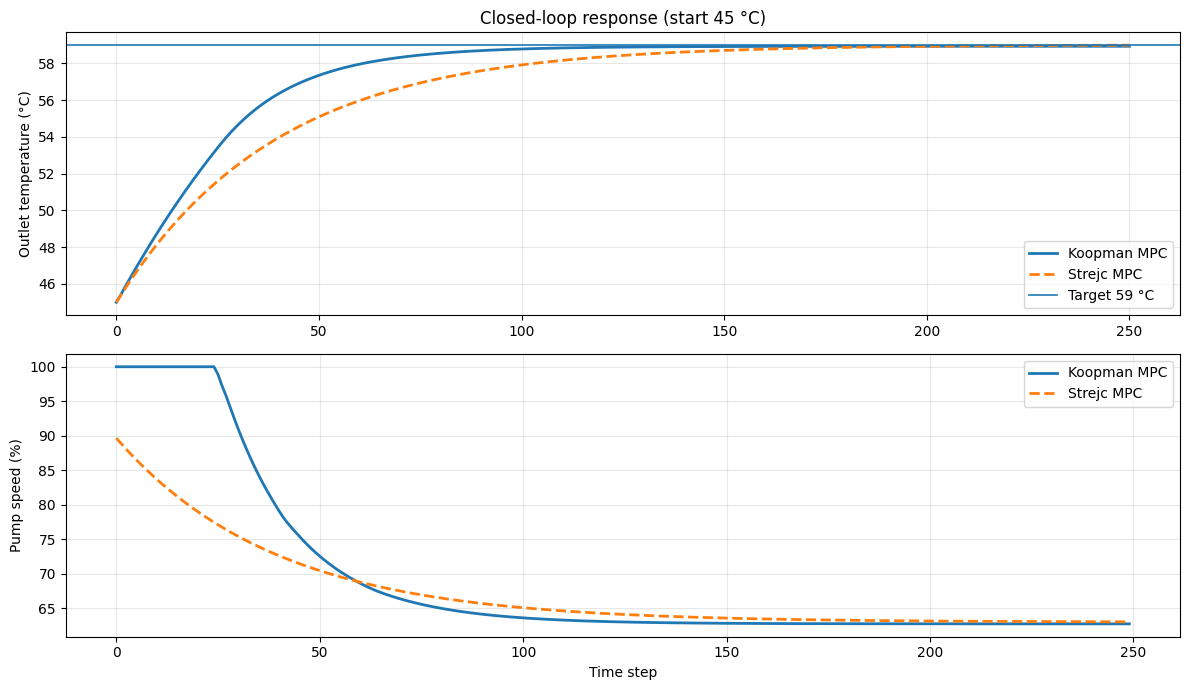

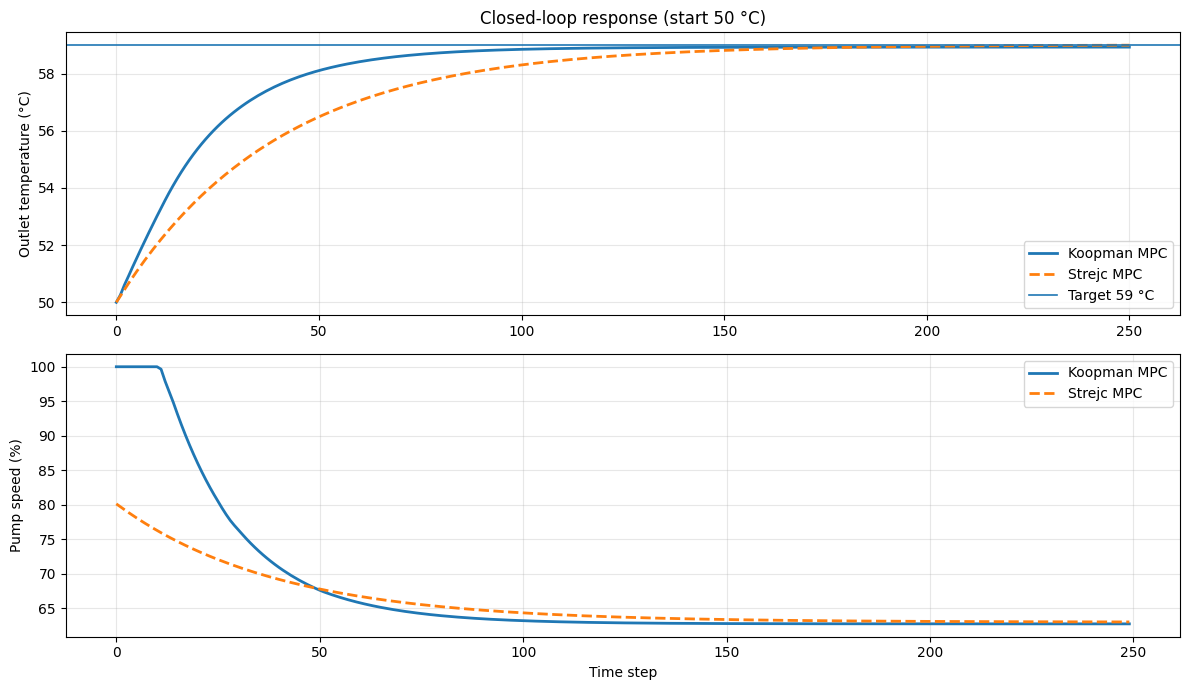

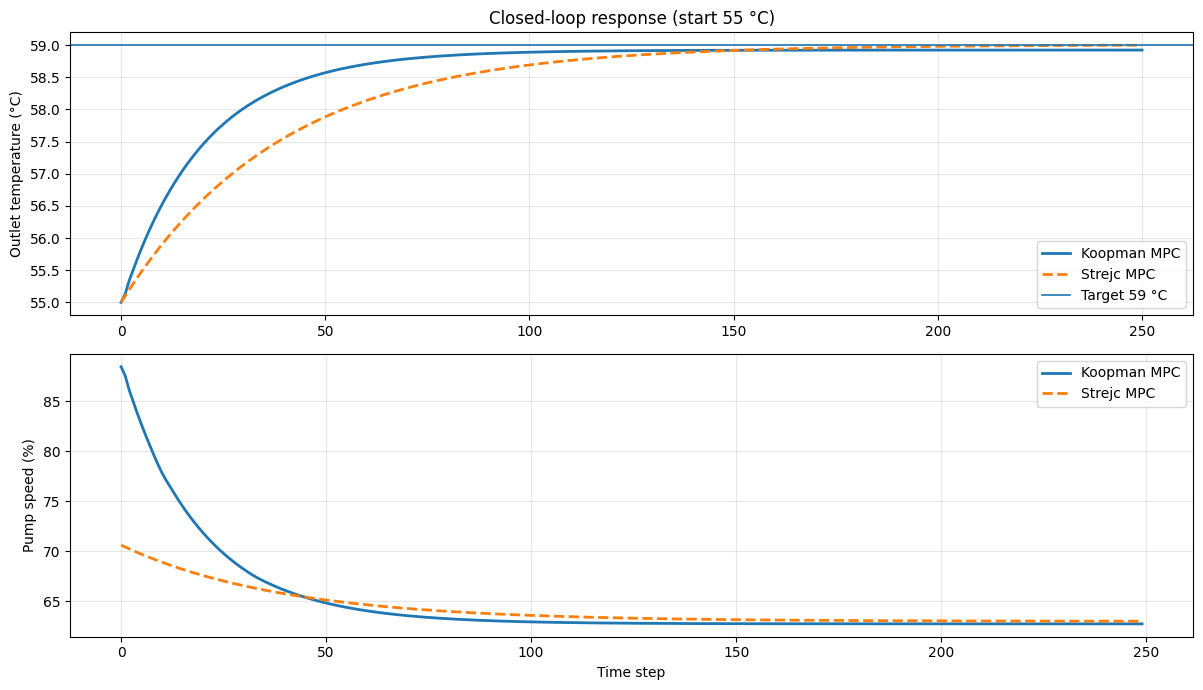

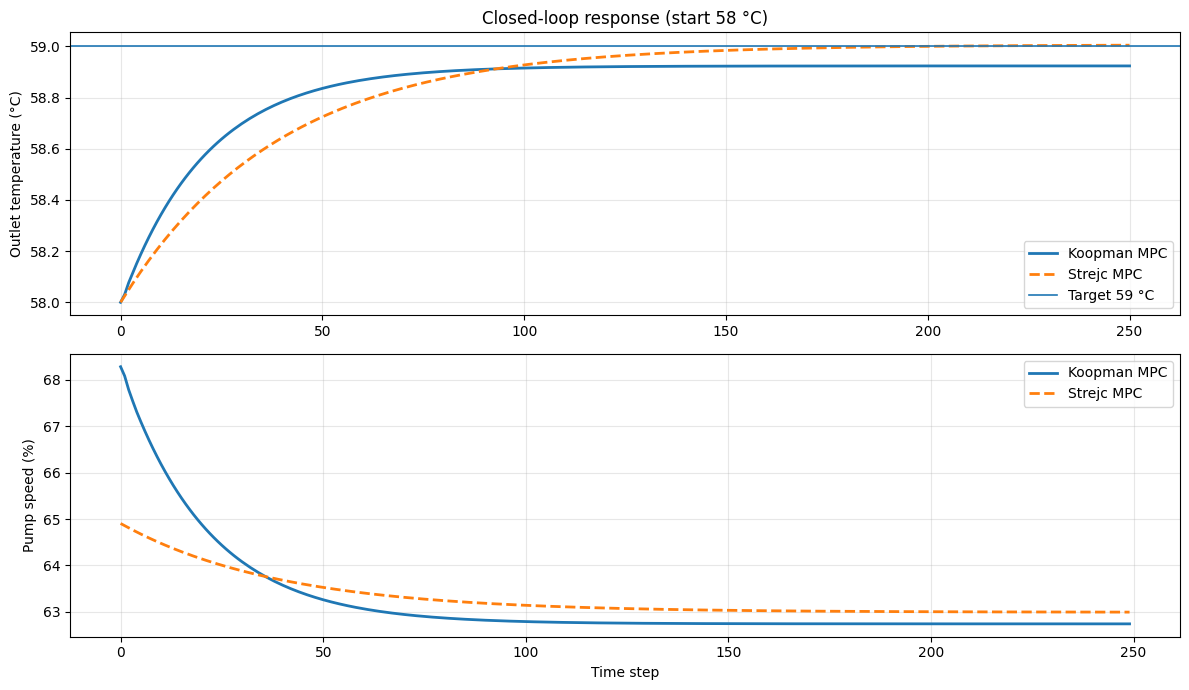

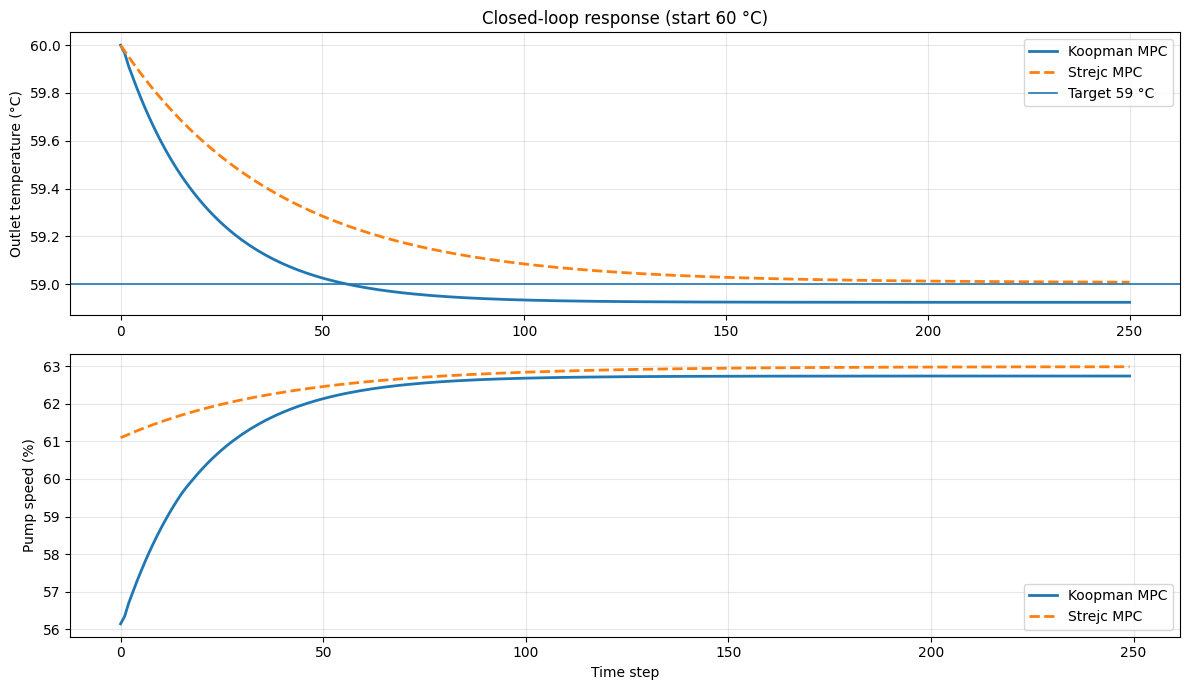

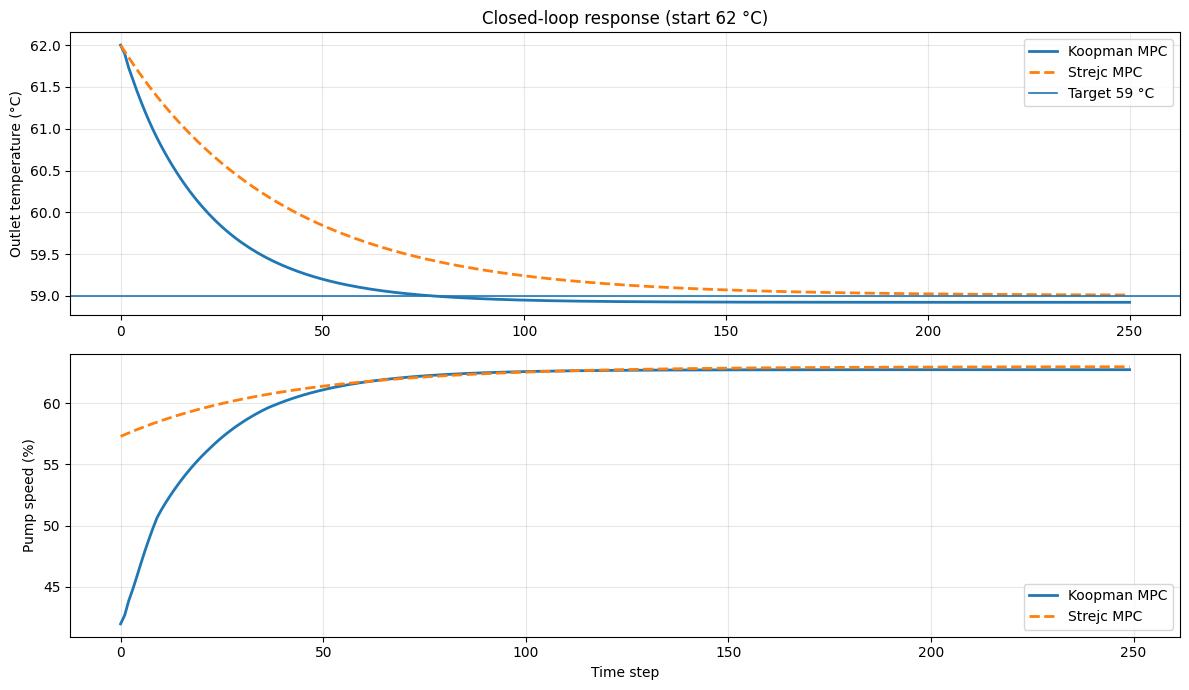

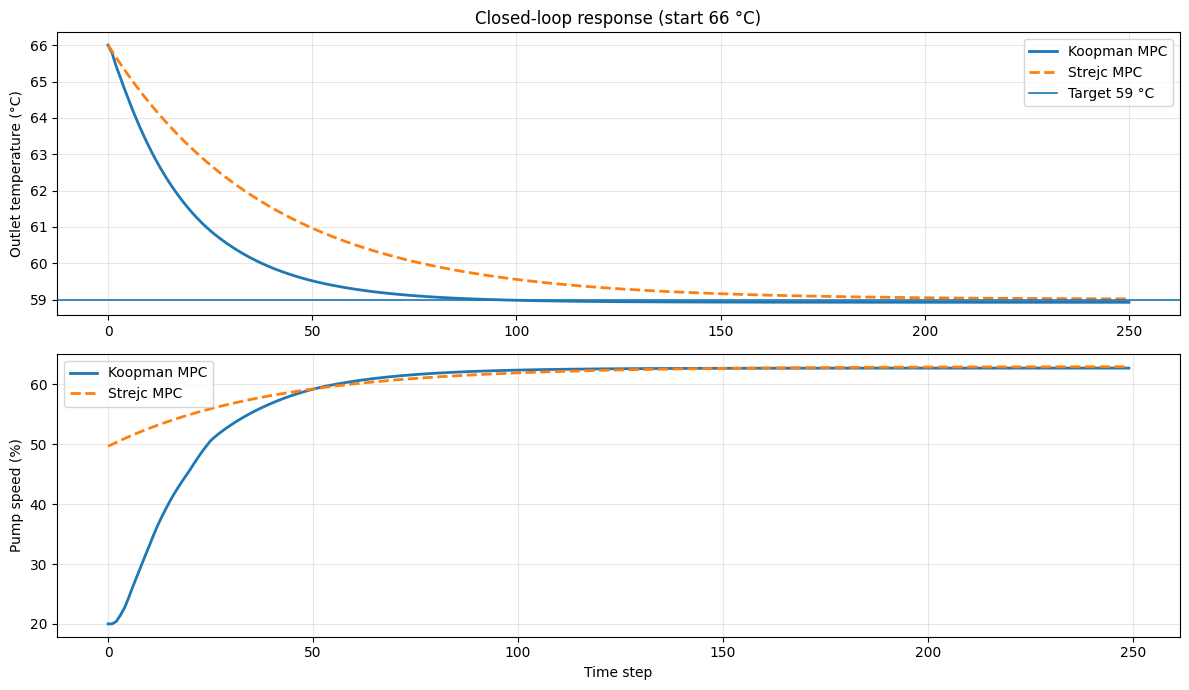

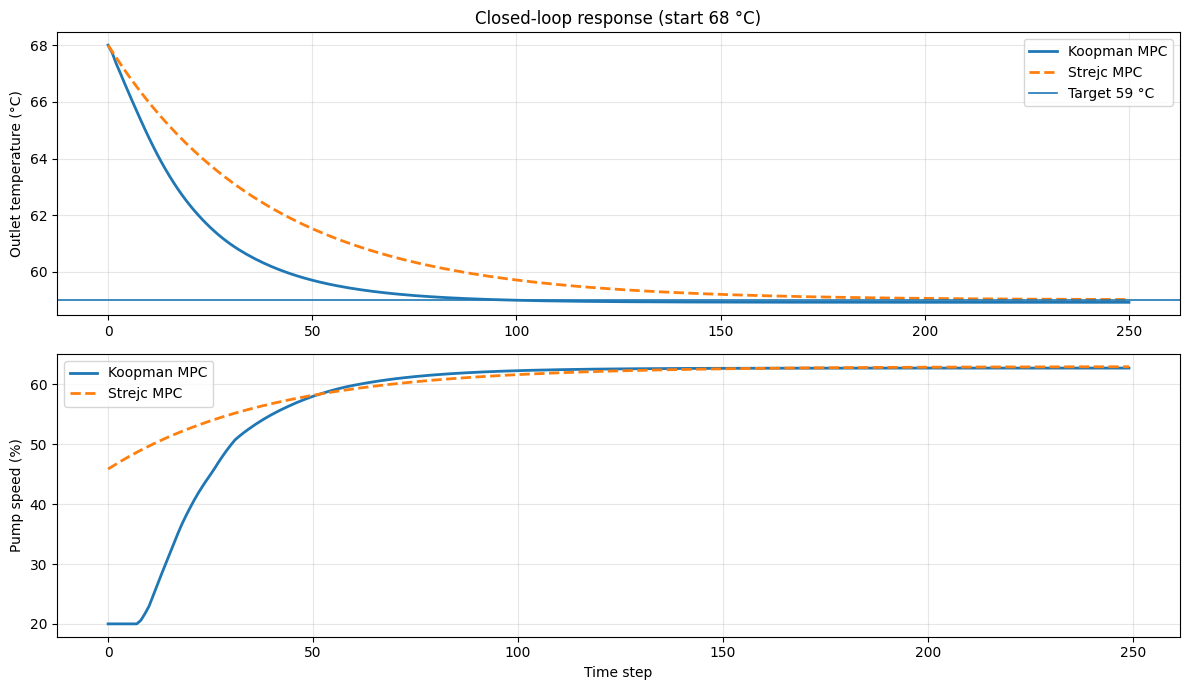

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.373284  3.973370  374.176707  554.688719  75659.280907  53764.282969
1  50  1.978362  2.553677  217.270463  356.103418  38423.687721  22207.911290
2  55  0.849841  1.133989  102.076582  157.518118   8299.287202   4379.184332
3  58  0.238022  0.282209   39.273413   38.654463    435.585348    271.217623
4  60  0.208576  0.285768   30.644881   41.067183    672.116895    278.102095
5  62  0.611631  0.853614   69.044342  120.501303   5360.756866   2481.409722
6  66  1.425269  1.989360  147.140366  279.369544  28756.337839  13477.294443
7  68  1.898223  2.557237  194.244926  358.803664  43368.632845  22269.871536

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [1]:
#bez qdu
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qu_koop = 1.0

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)
D_koop = np.zeros((1, 1), dtype=float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)
print("D_koop shape:", D_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

x59 = encode_y_to_x(59.0)
print("Decoded y from true encoder x(59):", decode_x_to_y_phys(x59))

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(
    A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
    dumin=None, dumax=None
):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(
    A, B, C, x0, yref_scaled,
    N=20, Qy=10.0, Qu=1.0,
    umin_scaled=None, umax_scaled=None,
    ymin_scaled=None
):
    """
    Koopman MPC in scaled coordinates:
        x+ = A x + B u_scaled
        y_scaled = C x
    optimization variable = ABSOLUTE scaled input
    """
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]

        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            yref_scaled=y_target_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qu=Qu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(encode_y_to_x(y_target)))

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
D_koop shape: (1, 1)
Decoded y from true encoder x(59): 58.946653551995
Decoded y from true encoder x(target): 58.946653551995
y_target_scaled = 0.0930284794888275
y_ref_from_model_scaled = 0.08553528232462011
y_bias_scaled = 0.007493197164207391
y_target_scaled_corr = 0.1005216766530349
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 58 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


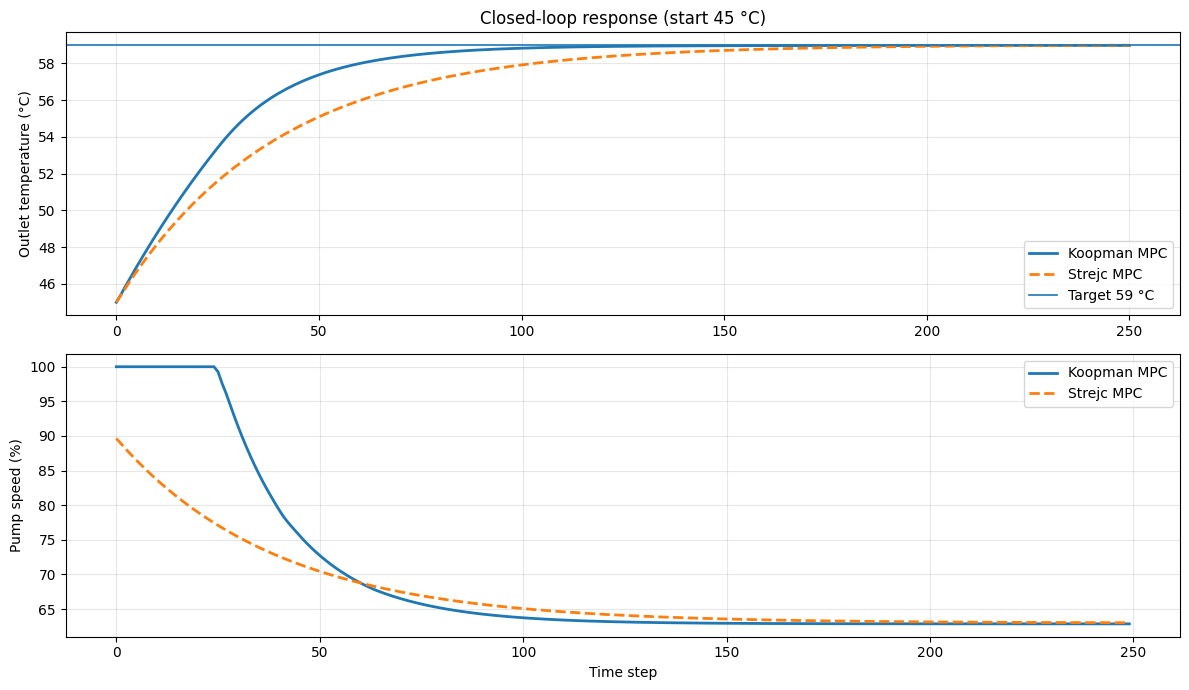

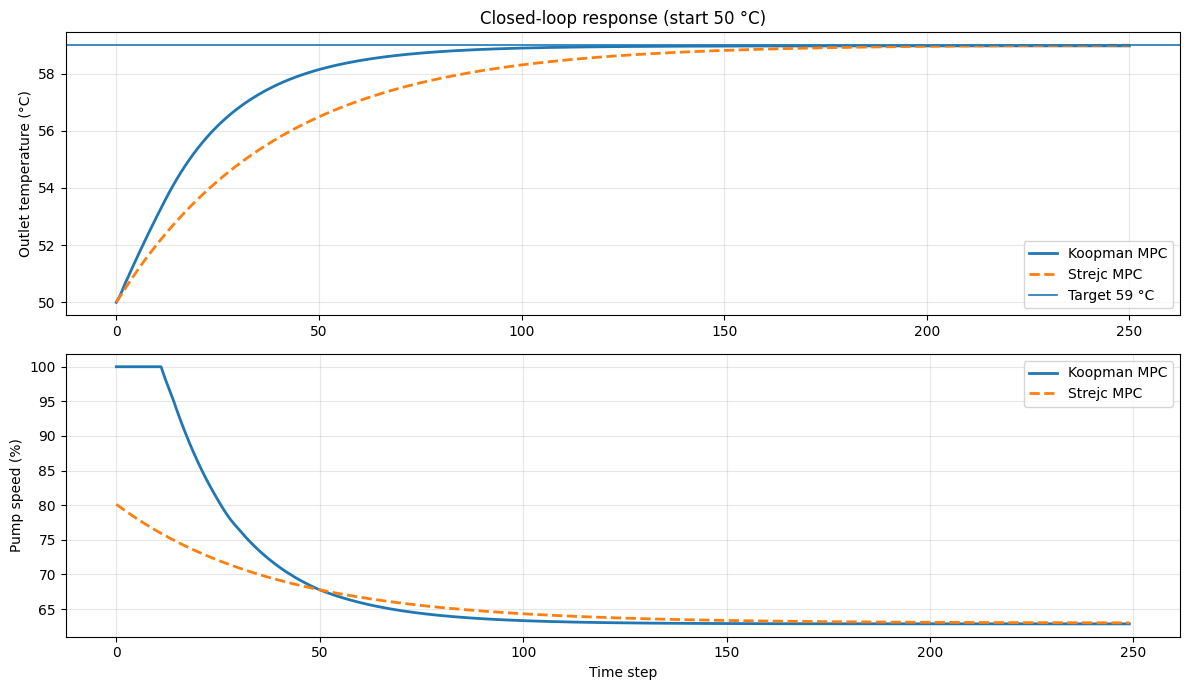

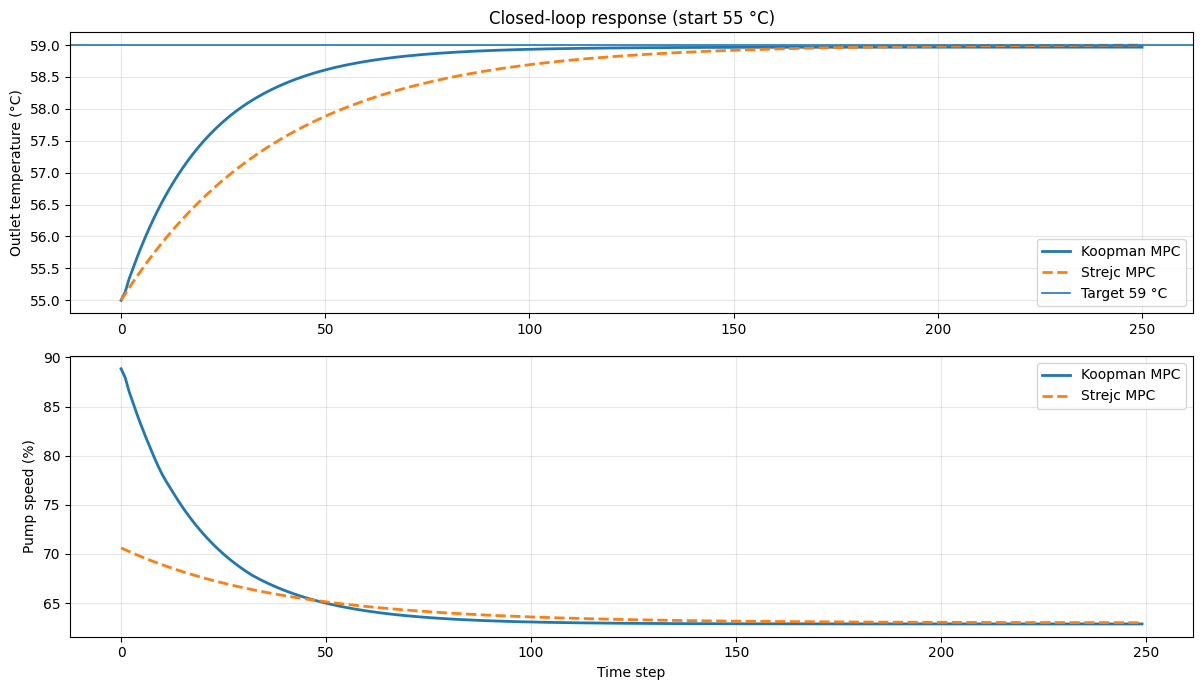

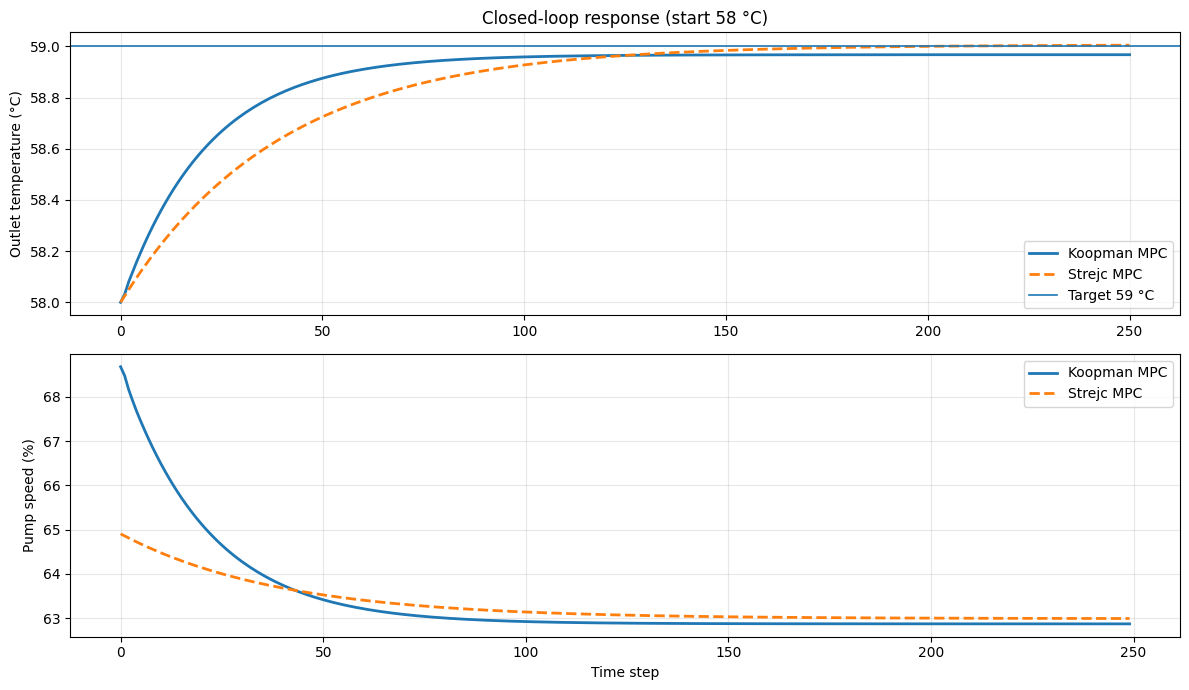

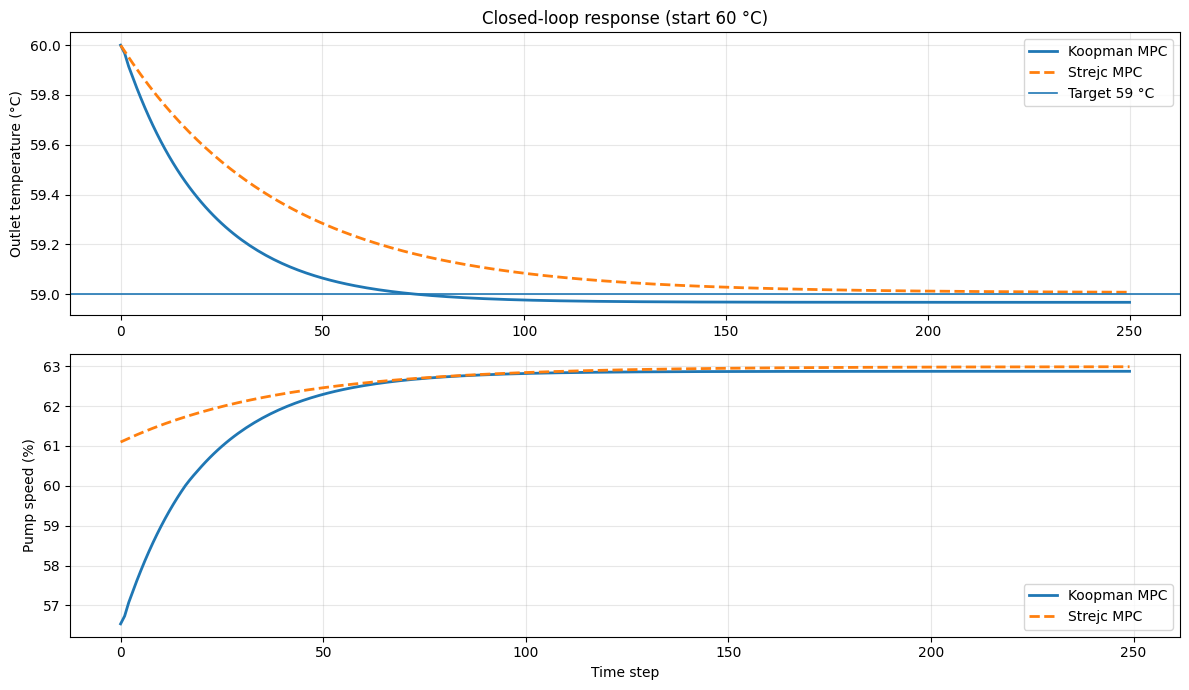

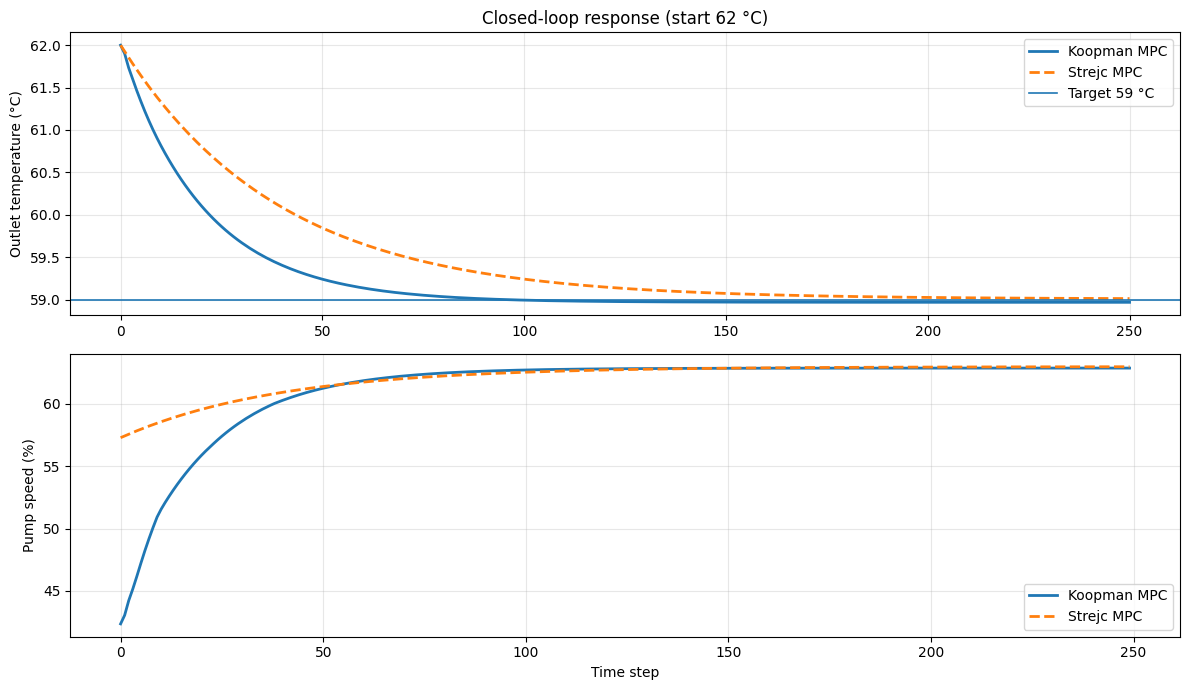

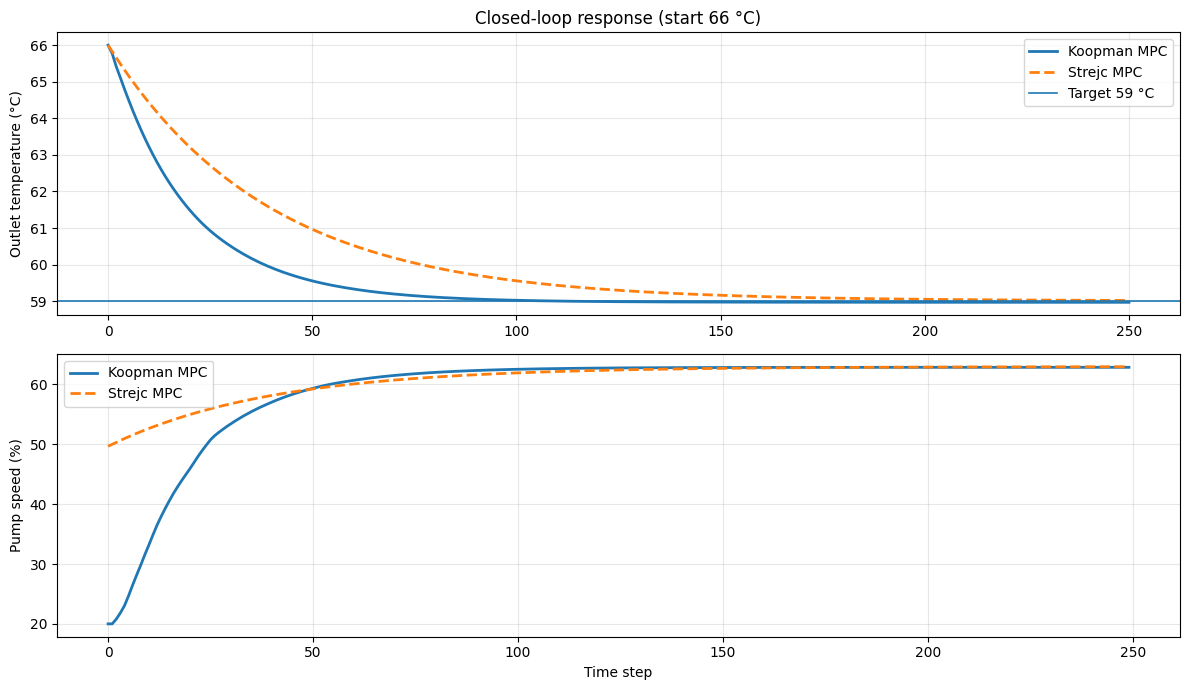

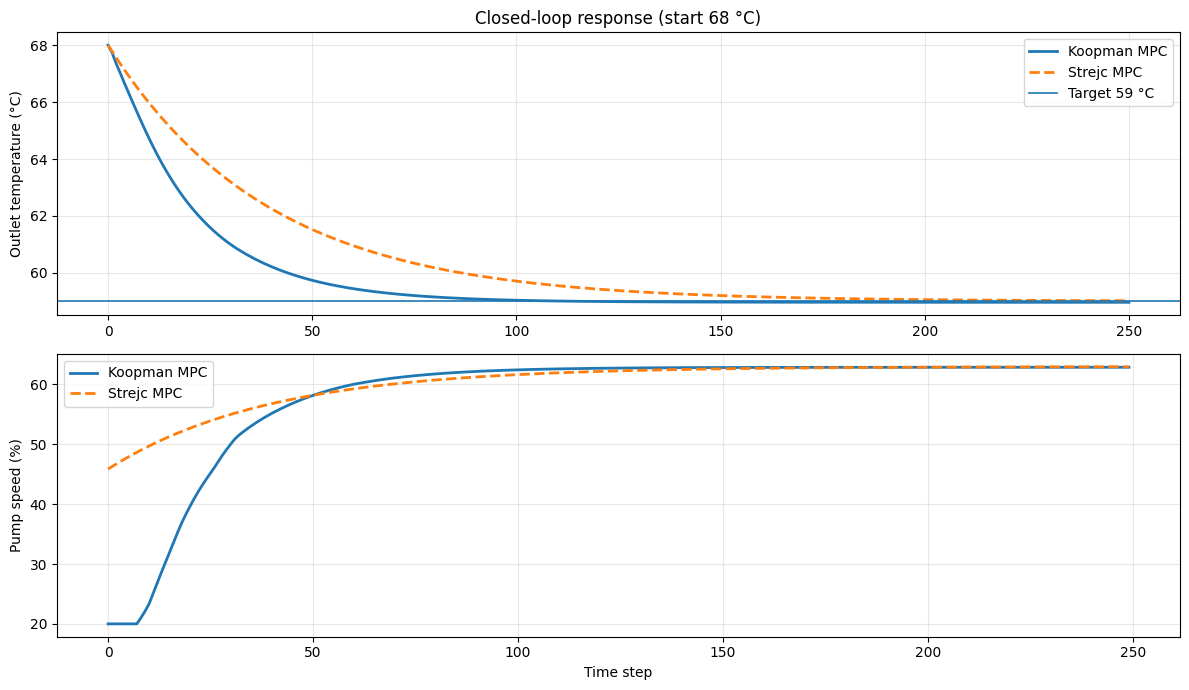

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.369992  3.973370  365.347046  554.688719  75976.679421  53764.282969
1  50  1.972602  2.553677  207.832099  356.103418  38745.458522  22207.911290
2  55  0.839276  1.133989   92.131014  157.518118   8517.419922   4379.184332
3  58  0.221013  0.282209   29.282486   38.654463    466.663960    271.217623
4  60  0.207300  0.285768   24.405431   41.067183    581.847169    278.102095
5  62  0.616607  0.853614   64.593508  120.501303   5145.422586   2481.409722
6  66  1.430943  1.989360  143.943110  279.369544  28327.462831  13477.294443
7  68  1.902460  2.557237  191.293672  358.803664  42944.537193  22269.871536

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
y_ref_from_model_scaled = 0.08553528232462011
y_target_scaled_corr = 0.1005216766530349
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [2]:
#koopmna corrected 
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qu_koop = 1.0

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)
D_koop = np.zeros((1, 1), dtype=float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)
print("D_koop shape:", D_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# sanity check
x59 = encode_y_to_x(59.0)
print("Decoded y from true encoder x(59):", decode_x_to_y_phys(x59))

# ============================================================
# MODEL TARGET CORRECTION
# ============================================================
x_ref = encode_y_to_x(y_target)
y_ref_from_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_from_model_phys = decode_x_to_y_phys(x_ref)

y_bias_scaled = y_target_scaled - y_ref_from_model_scaled
y_target_scaled_corr = y_target_scaled + y_bias_scaled

print("Decoded y from true encoder x(target):", y_ref_from_model_phys)
print("y_target_scaled =", y_target_scaled)
print("y_ref_from_model_scaled =", y_ref_from_model_scaled)
print("y_bias_scaled =", y_bias_scaled)
print("y_target_scaled_corr =", y_target_scaled_corr)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(
    A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
    dumin=None, dumax=None
):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(
    A, B, C, x0, yref_scaled,
    N=20, Qy=10.0, Qu=1.0,
    umin_scaled=None, umax_scaled=None,
    ymin_scaled=None
):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]

        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            yref_scaled=y_target_scaled_corr,
            N=N_koop,
            Qy=Qy_koop,
            Qu=Qu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_from_model_scaled =", y_ref_from_model_scaled)
print("y_target_scaled_corr =", y_target_scaled_corr)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
Decoded y from true encoder x(target): 58.946653551995
Model-consistent target scaled: 0.08553528232462011
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


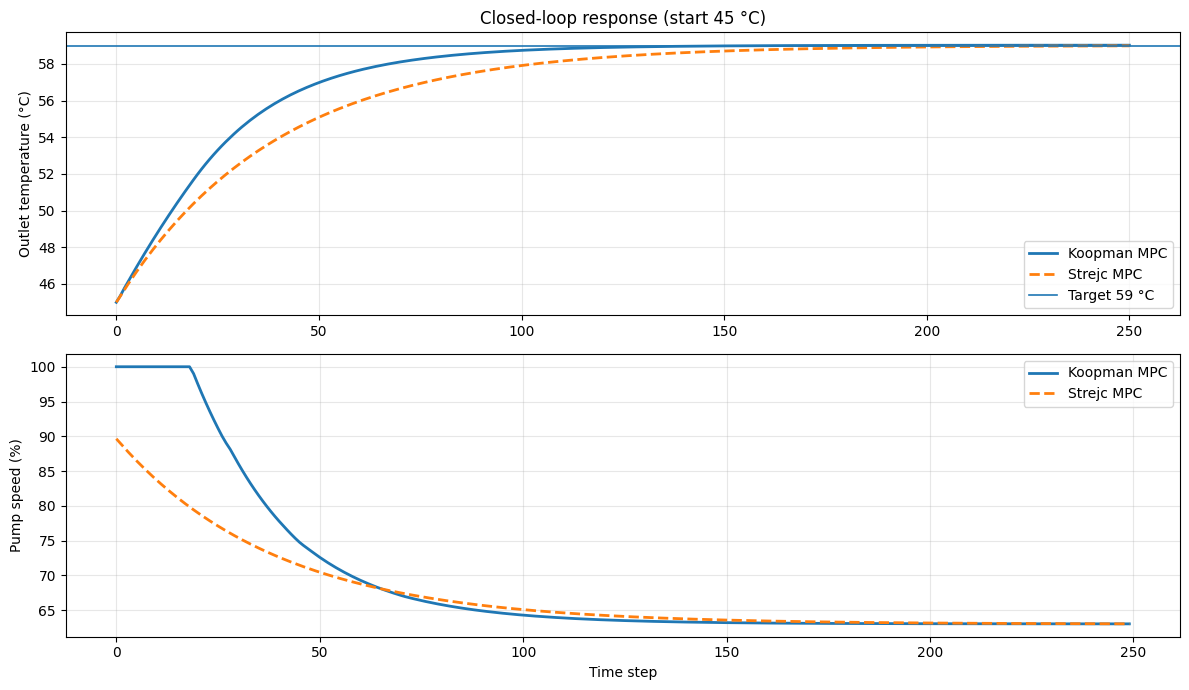

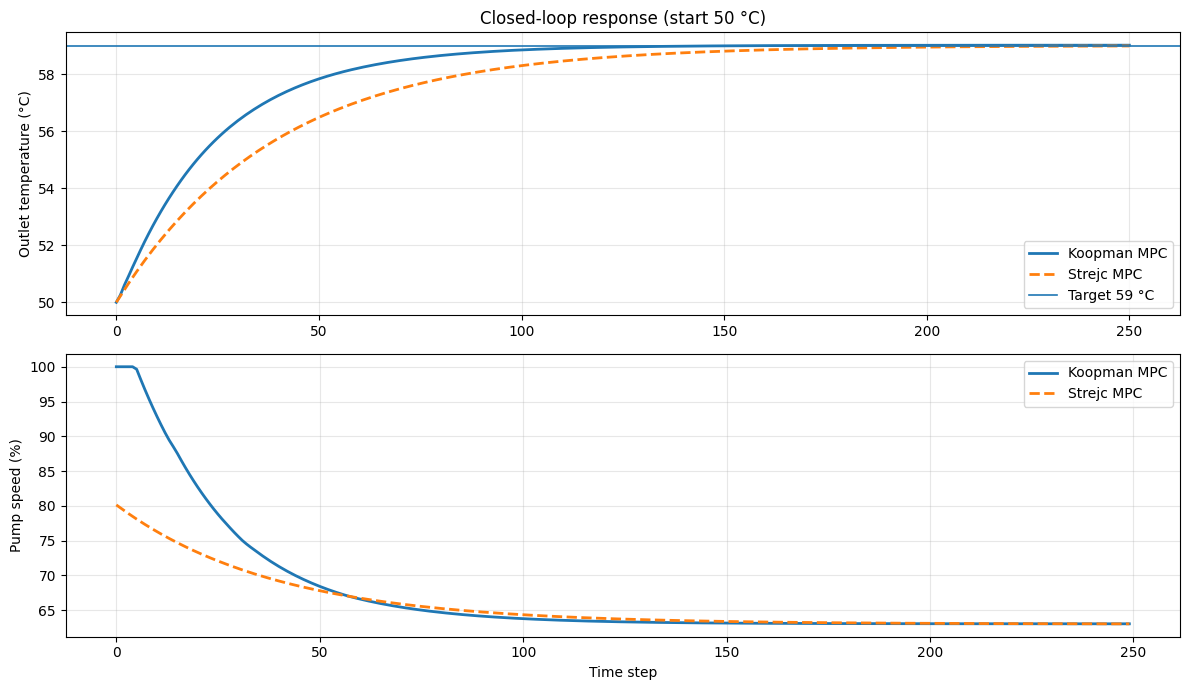

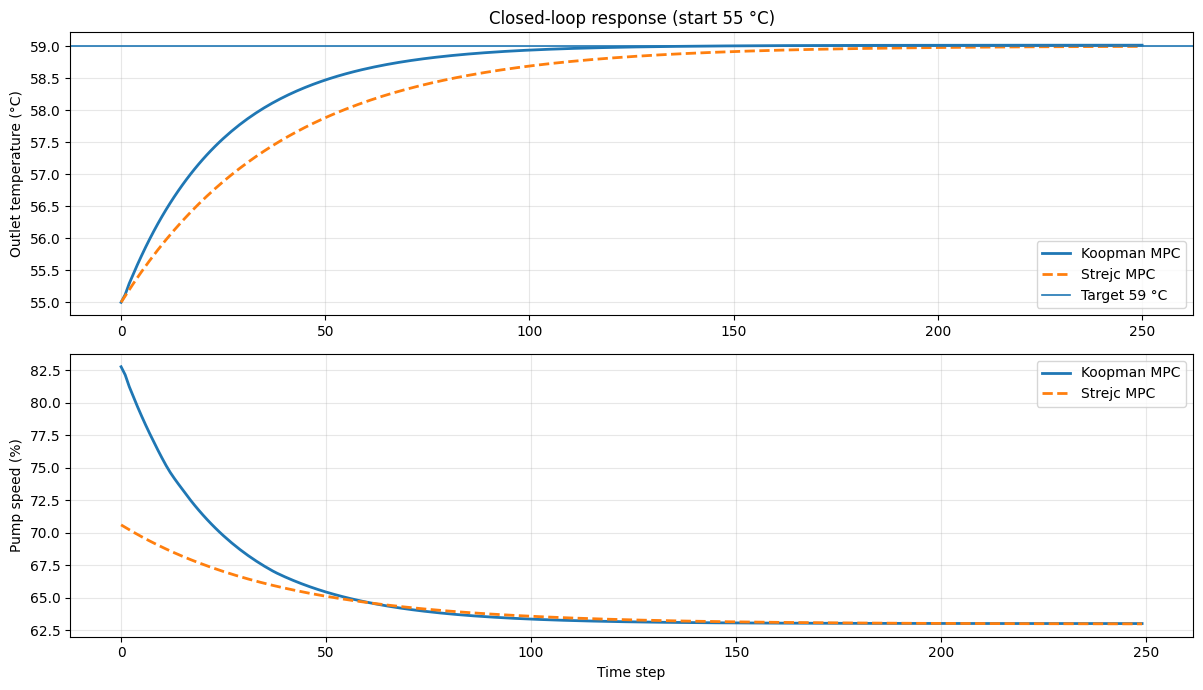

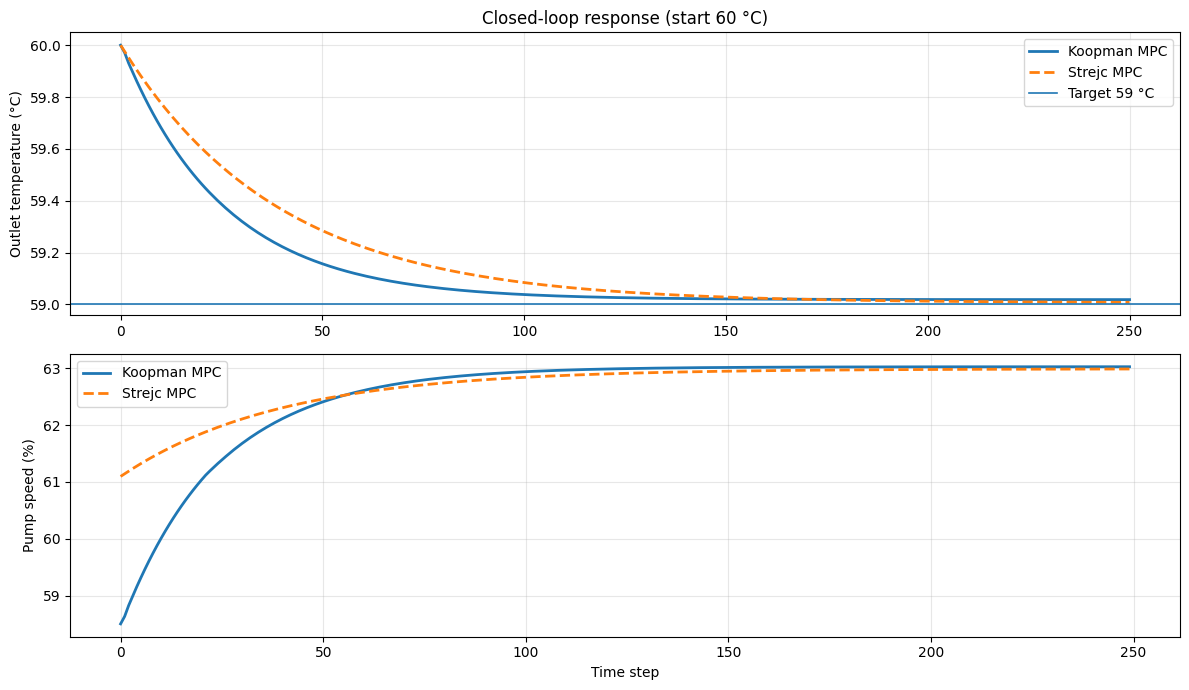

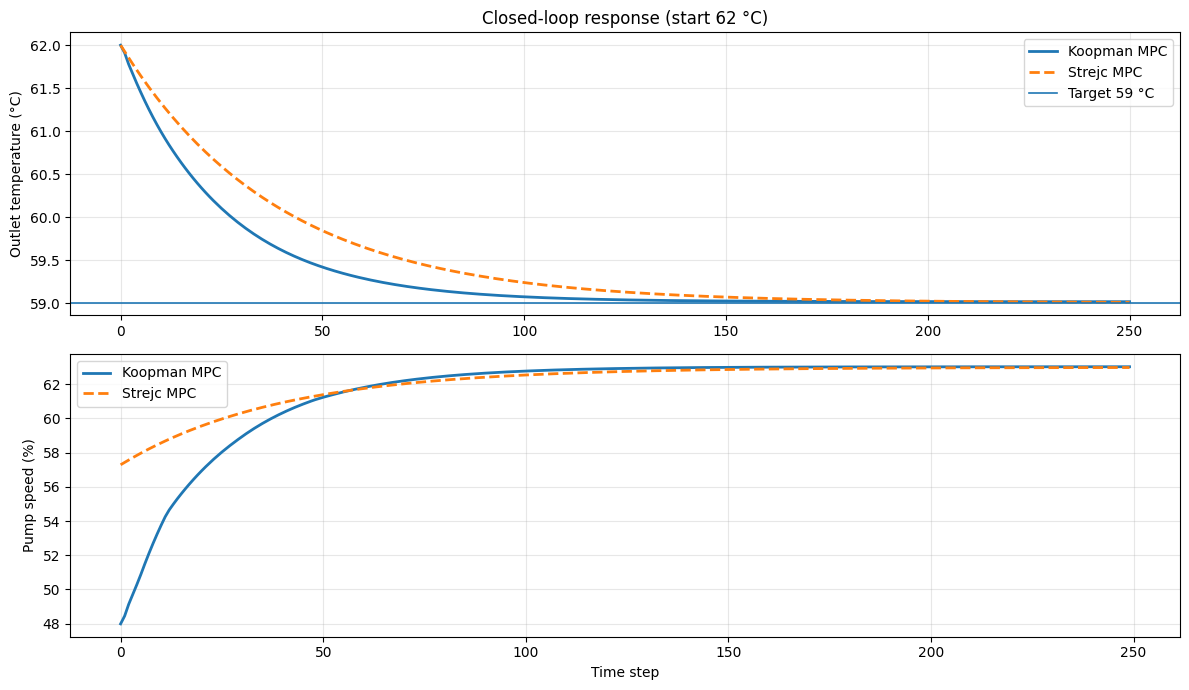

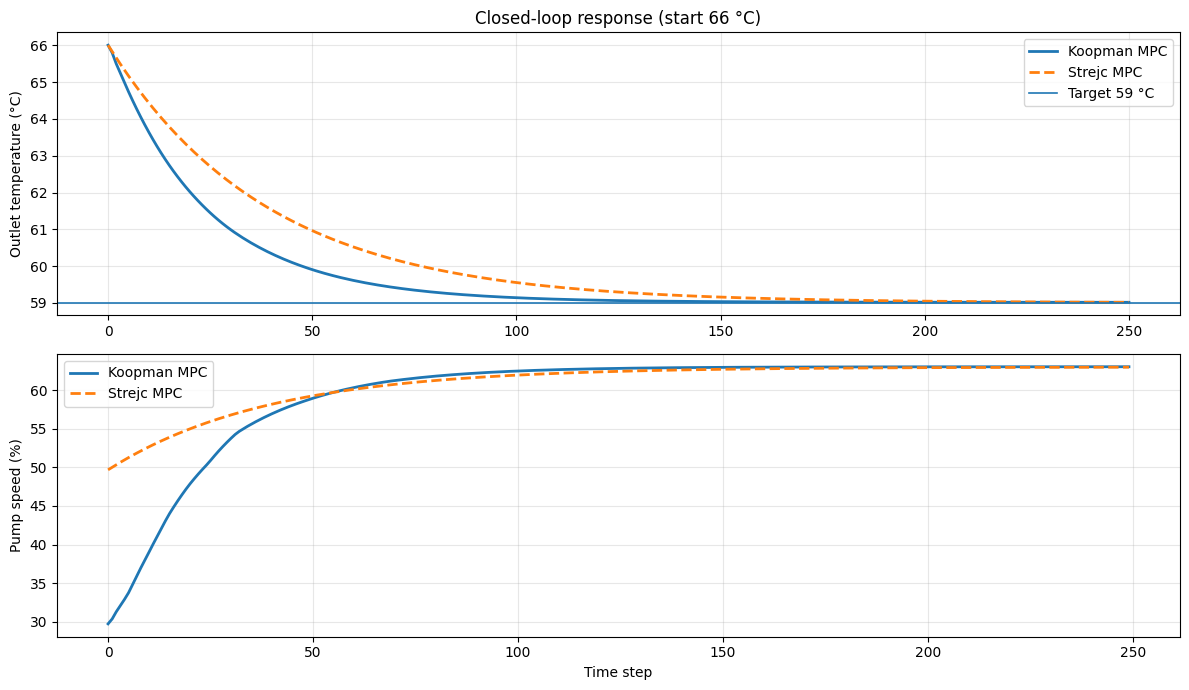

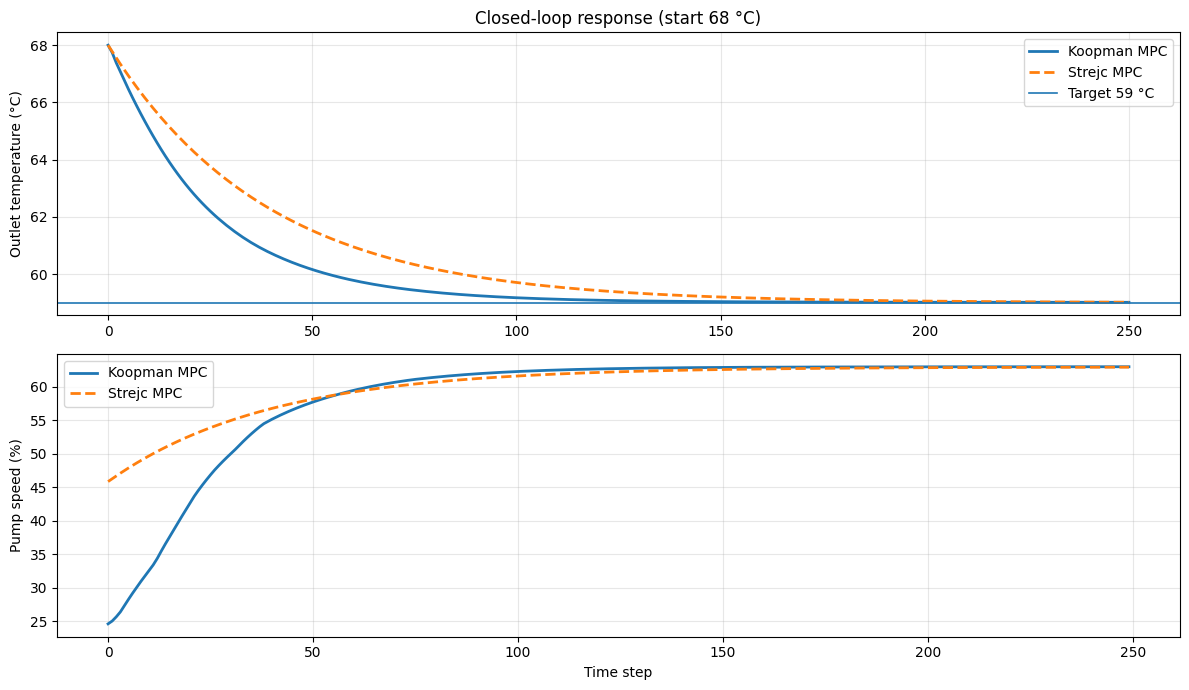

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.416313  3.973370  384.135268  554.688719  71354.305393  53764.282969
1  50  2.050799  2.553677  226.435310  356.103418  34116.161189  22207.911290
2  55  0.905894  1.133989  100.961466  157.518118   6821.107426   4379.184332
3  60  0.235372  0.285768   30.172966   41.067183    396.895485    278.102095
4  62  0.685019  0.853614   80.377834  120.501303   3800.867828   2481.409722
5  66  1.574239  1.989360  177.353590  279.369544  21467.807956  13477.294443
6  68  2.049015  2.557237  229.542918  358.803664  34350.067878  22269.871536

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
y_ref_model_scaled = 0.08553528232462011
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [4]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qx_koop = 1.0
QxN_koop = 100.0
Qu_koop = 1.0

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# model-consistent target
x_ref = encode_y_to_x(y_target)
y_ref_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_model_phys = decode_x_to_y_phys(x_ref)

print("Decoded y from true encoder x(target):", y_ref_model_phys)
print("Model-consistent target scaled:", y_ref_model_scaled)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
                   dumin=None, dumax=None):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(A, B, C, x0, xref, yref_scaled,
                           N=20, Qy=10.0, Qx=1.0, QxN=100.0, Qu=1.0,
                           umin_scaled=None, umax_scaled=None,
                           ymin_scaled=None):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    xref = xref.reshape(-1, 1)
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qx * cp.sum_squares(X[:, [k]] - xref)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    # strong terminal pull to steady state
    objective += QxN * cp.sum_squares(X[:, [N]] - xref)

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]
        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            xref=x_ref,
            yref_scaled=y_ref_model_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qx=Qx_koop,
            QxN=QxN_koop,
            Qu=Qu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_model_scaled =", y_ref_model_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
Decoded y from true encoder x(target): 58.946653551995
Model-consistent target scaled: 0.08553528232462011
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


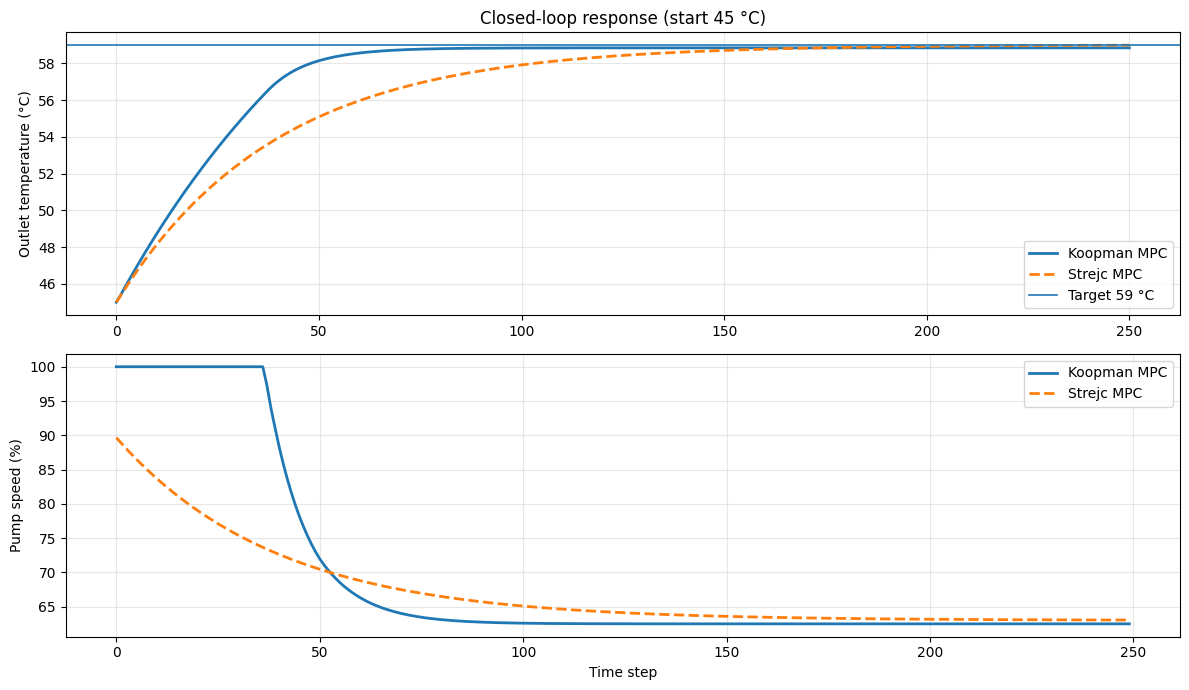

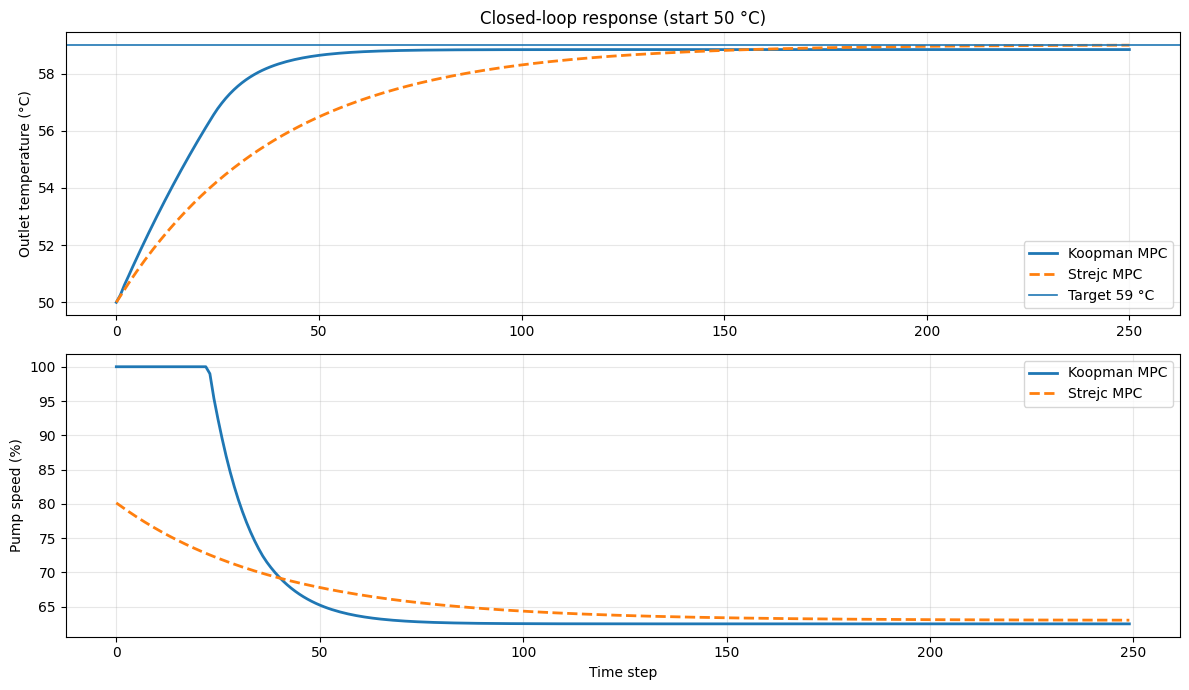

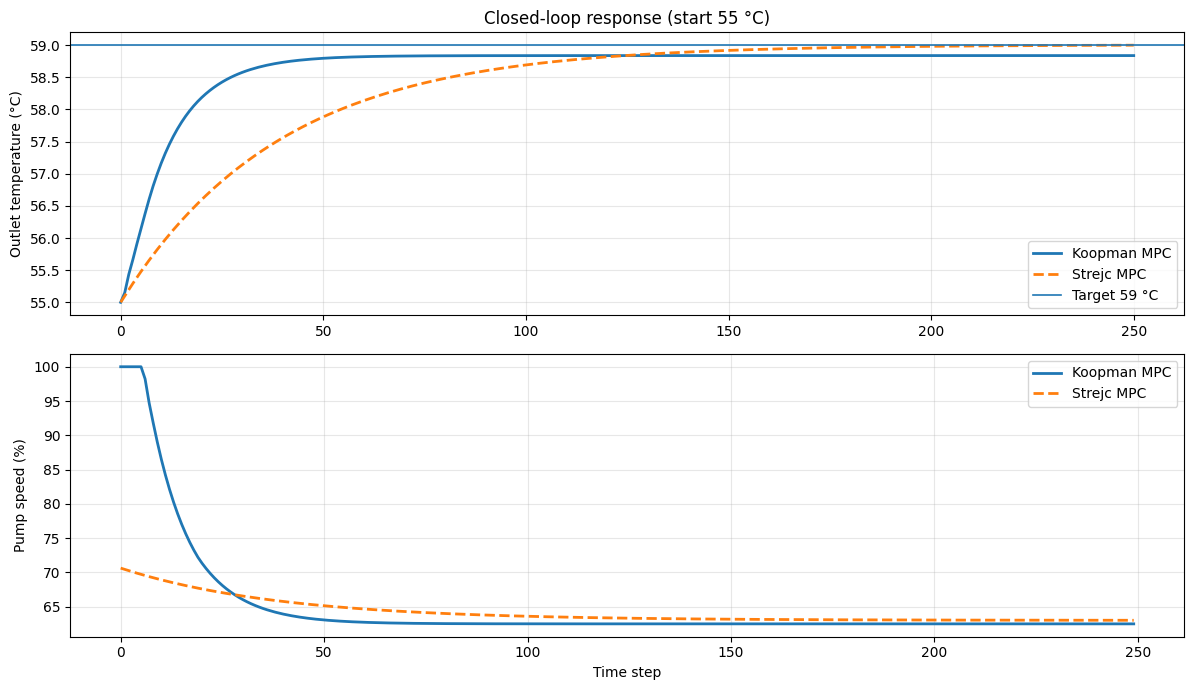

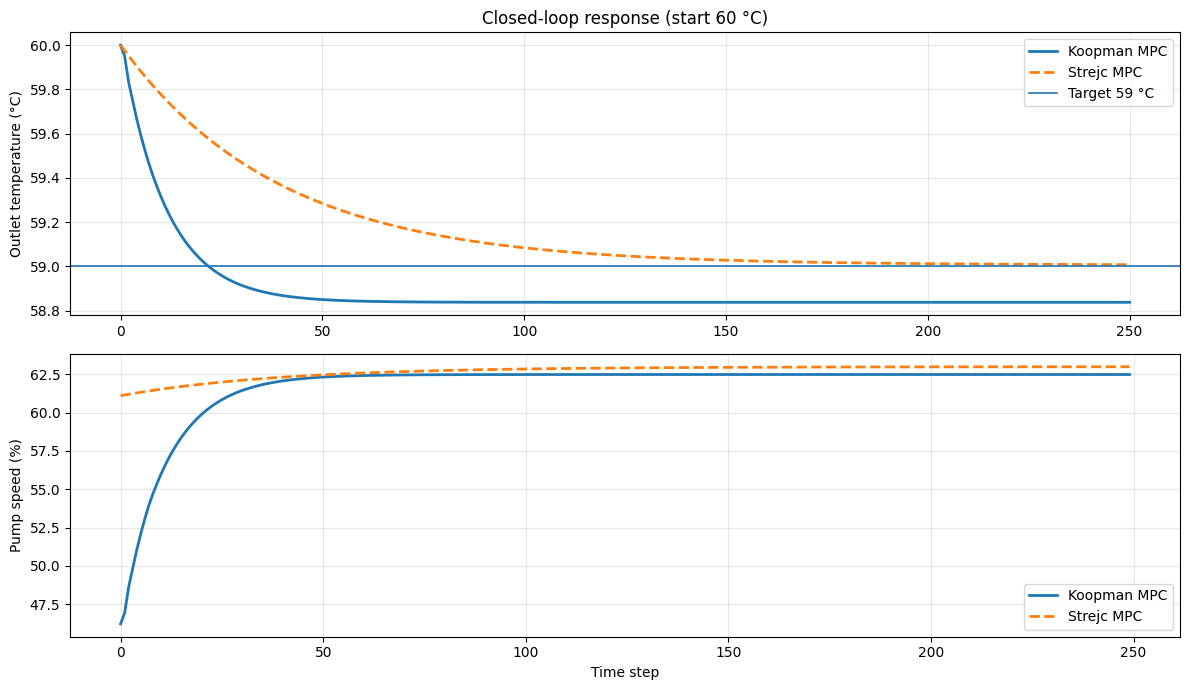

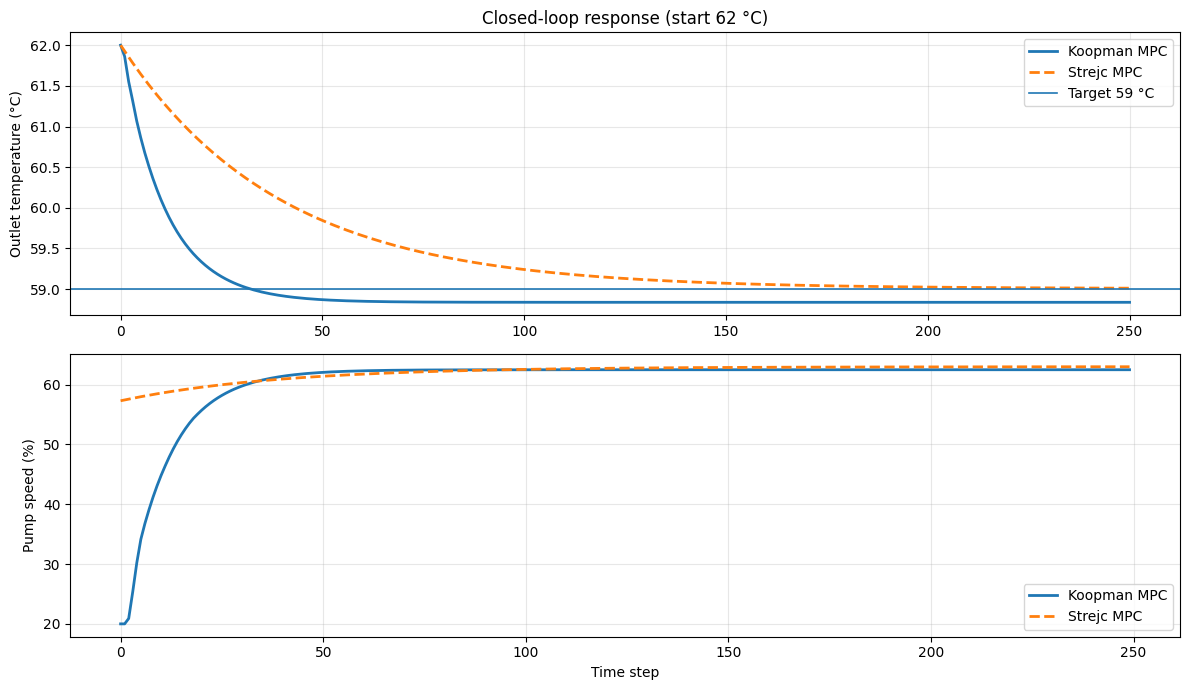

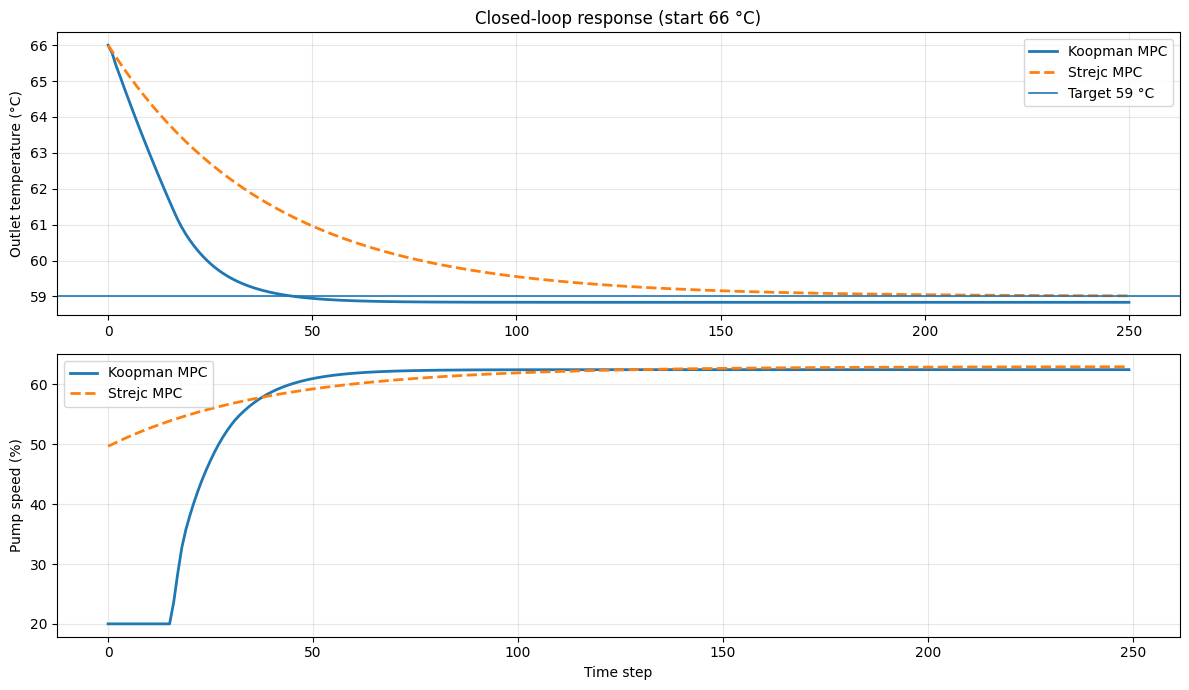

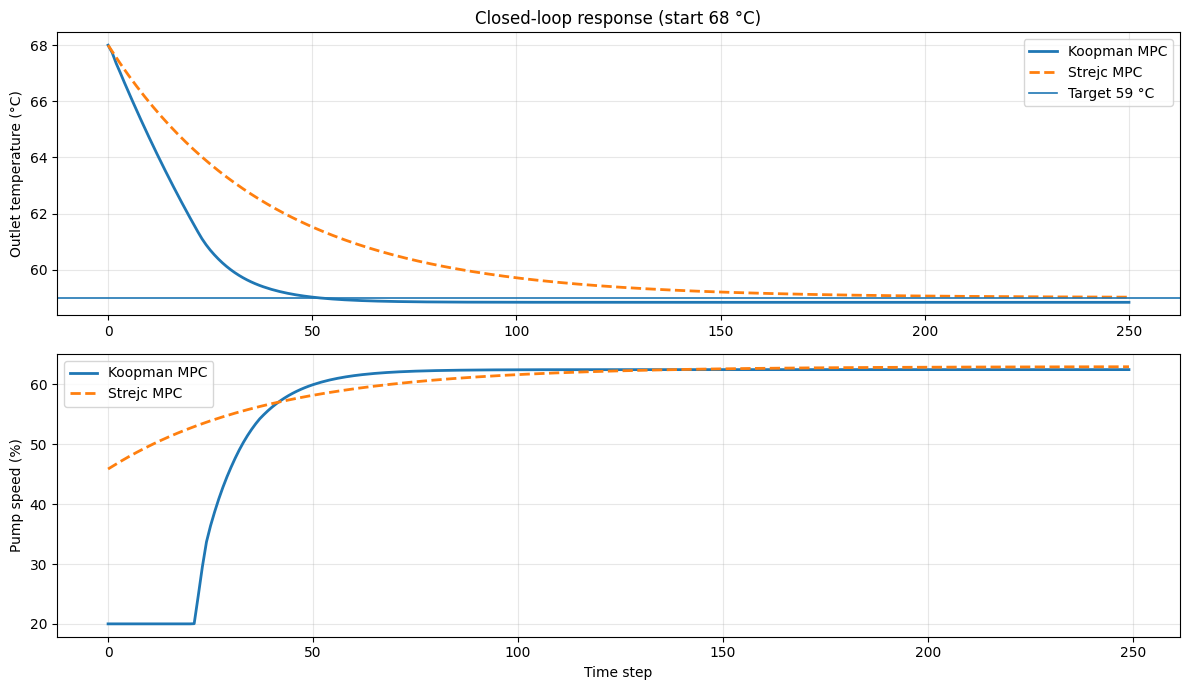

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S          Obj_K         Obj_S
0  45  3.330107  3.973370  354.050440  554.688719  195704.906506  53764.282969
1  50  1.904124  2.553677  198.310483  356.103418   83834.363079  22207.911290
2  55  0.700253  1.133989   87.620068  157.518118   21099.328454   4379.184332
3  60  0.206344  0.285768   43.387060   41.067183    2411.977254    278.102095
4  62  0.474527  0.853614   62.698897  120.501303   15802.504347   2481.409722
5  66  1.312034  1.989360  129.648766  279.369544   59248.575393  13477.294443
6  68  1.814593  2.557237  176.248309  358.803664   89585.563857  22269.871536

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
y_ref_model_scaled = 0.08553528232462011
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


In [8]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC (analogicka ucelovka ako Strejc)
N_koop = 20
Qy_koop = 50.0
Qu_koop = 1.0

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return float((C_koop @ x_latent).item())

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return float(scaler.inverse_transform(np.array([[y_scaled]])).item())

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# model-consistent target
x_ref = encode_y_to_x(y_target)
y_ref_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_model_phys = decode_x_to_y_phys(x_ref)

print("Decoded y from true encoder x(target):", y_ref_model_phys)
print("Model-consistent target scaled:", y_ref_model_scaled)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
                   dumin=None, dumax=None):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(A, B, C, x0, yref_scaled,
                           N=20, Qy=10.0, Qu=1.0,
                           u_ss_scaled=0.0,
                           umin_scaled=None, umax_scaled=None,
                           ymin_scaled=None):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]
        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            yref_scaled=y_ref_model_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qu=Qu_koop,
            u_ss_scaled=u_ss_scaled,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_model_scaled =", y_ref_model_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))

pretrenovanie FORCE_RETRAIN_ARX = True

scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
Loaded cached ARX theta from: C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\data\theta_abs.npy
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
ARX bias  = 0.8084211946110558
Operating point:
y_ss = 58.337700739046234
u_ss = 61.0
steady output at u_ss = 58.34881227796579
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.08705778123716539
y_target_scaled = 0.0
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
Decoded y from true encoder x(target): 58.353845533791194
Model-consistent target scaled: 0.0022677448025833907
Chosen Koopman reference scaled: 0.0

Simulating T0 = 45 °C

Simulating T0 = 50 °C

Simulating T0 = 55 °C

Simulating T0 = 60 °C

Simulating T0 = 62 °C

Simula

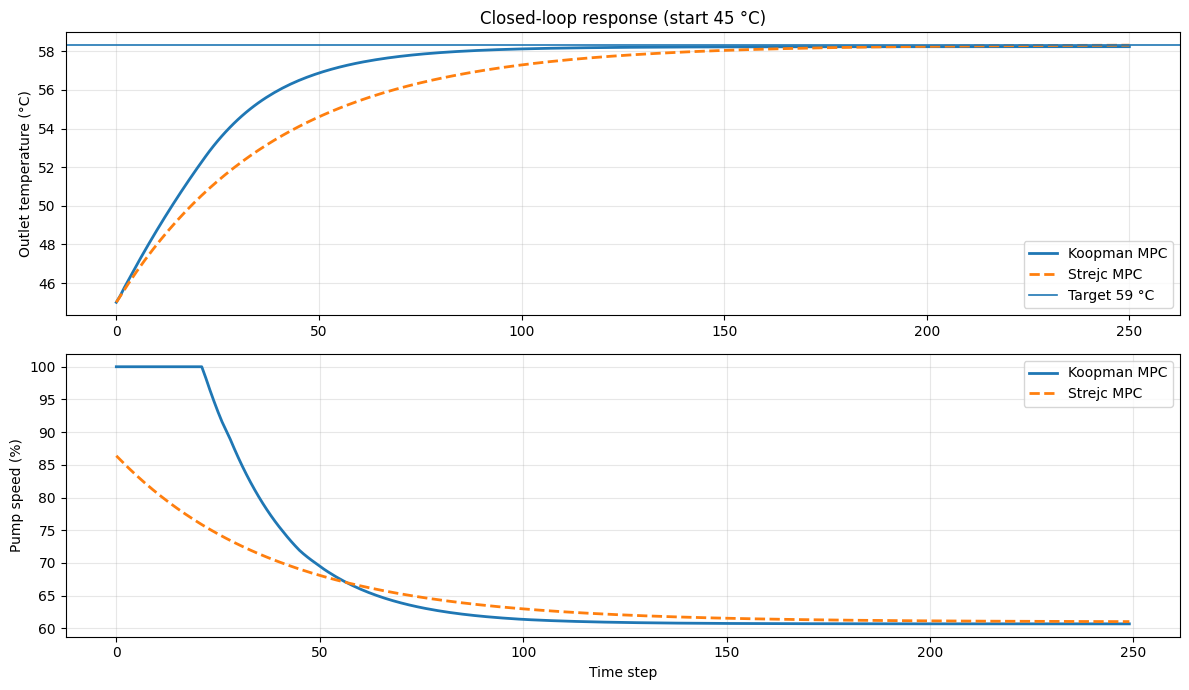

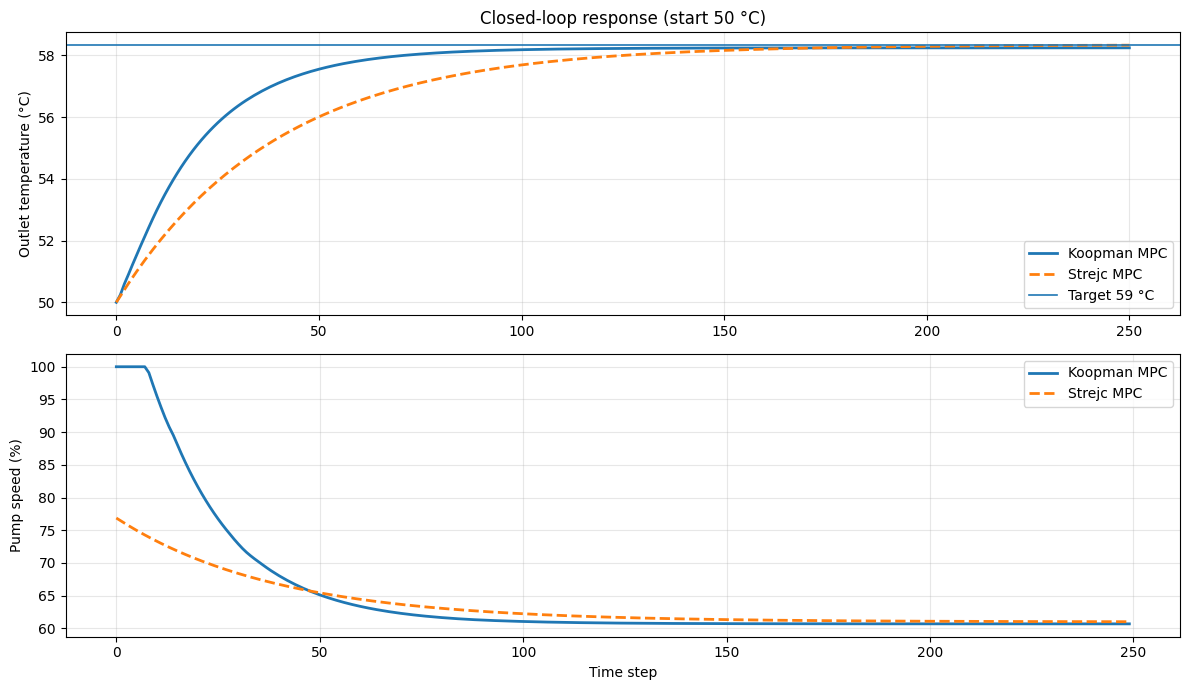

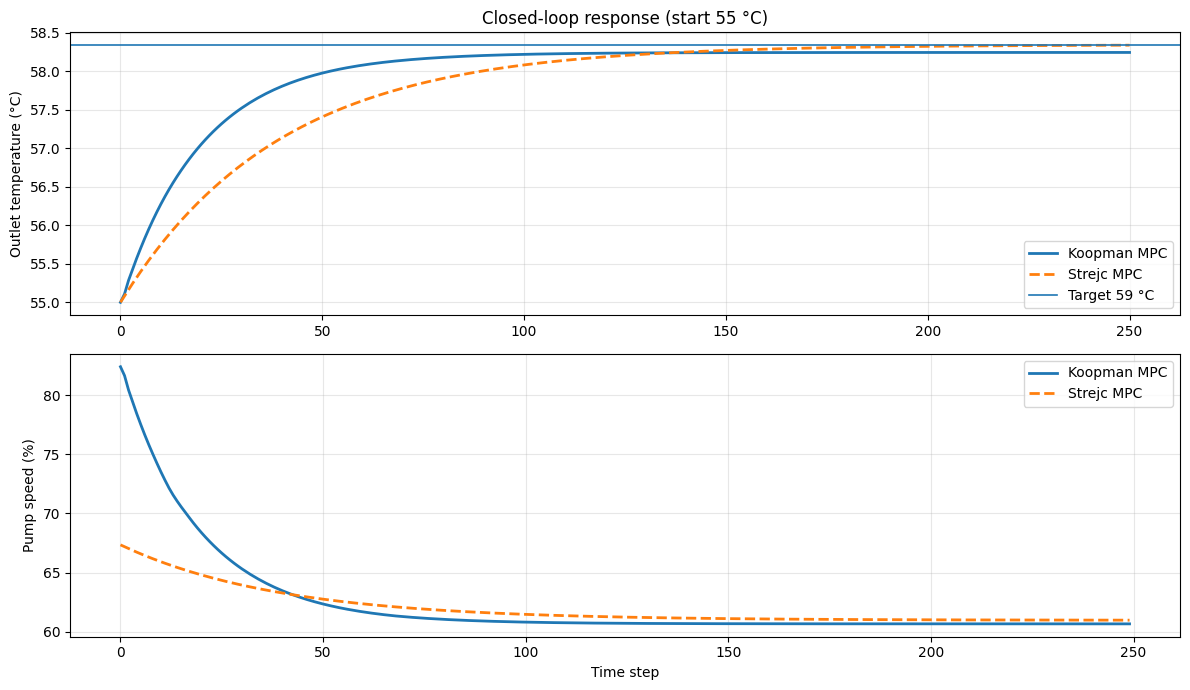

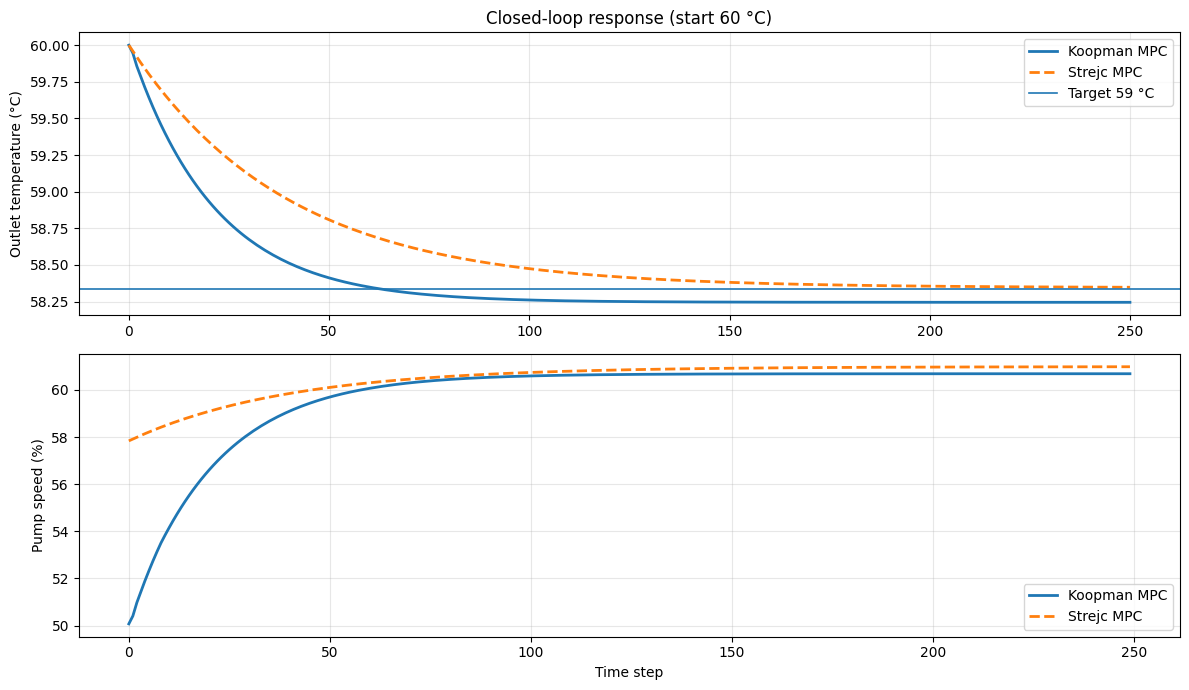

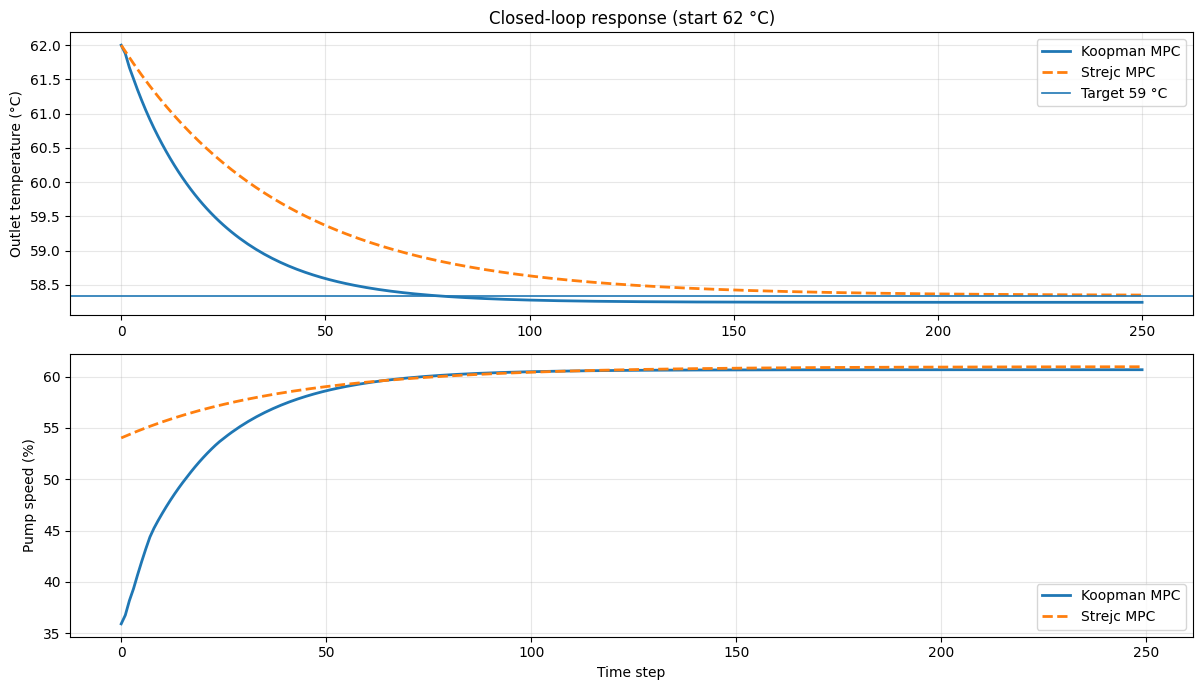

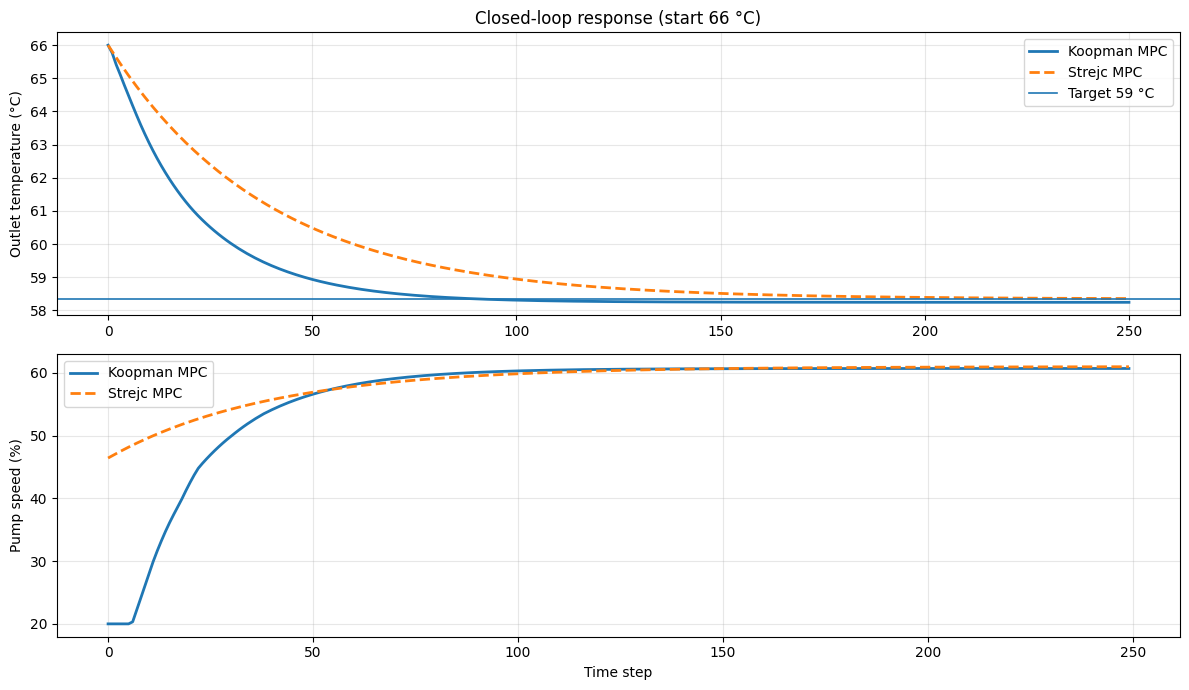

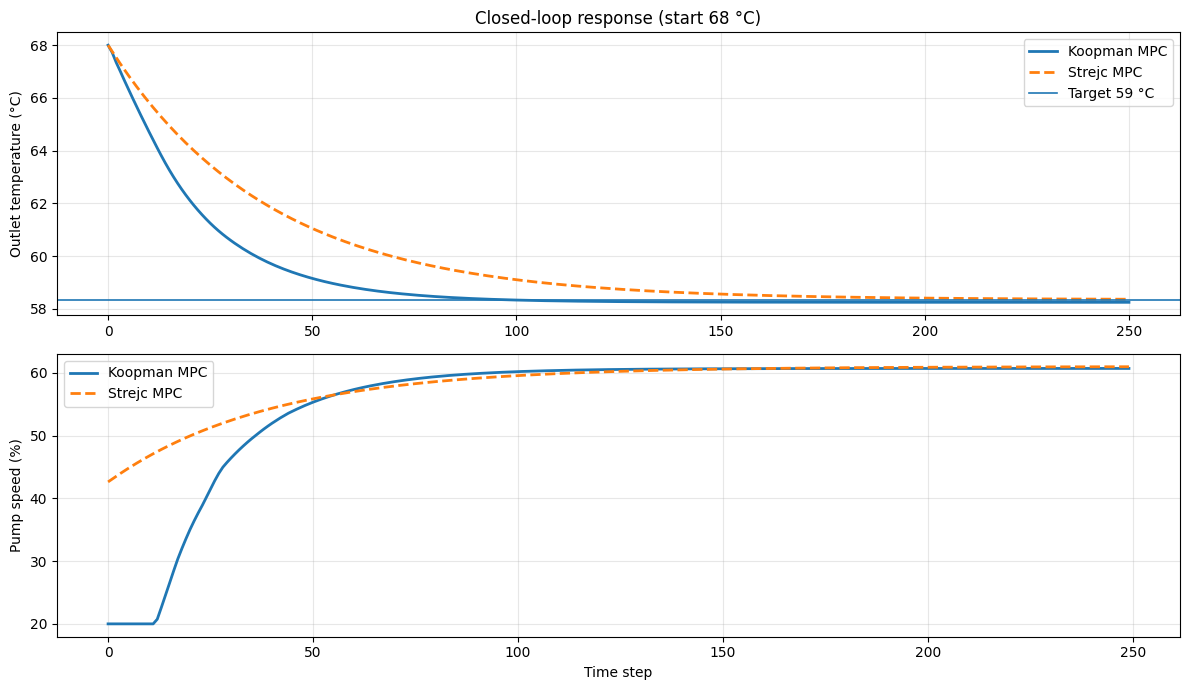


Summary:
   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.140491  3.785203  346.207487  528.296953  72320.578044  48792.629165
1  50  1.790058  2.365510  198.478771  329.711652  35035.692291  19055.730715
2  55  0.710479  0.945825   90.224308  131.132816   5818.474414   3046.476987
3  60  0.345280  0.473920   46.009783   67.458949   1705.065176    764.867980
4  62  0.752449  1.041780   85.194954  146.893069   7800.945337   3695.964900
5  66  1.591844  2.177528  166.735382  305.761310  32643.593741  16147.428204
6  68  2.089399  2.745404  217.551998  385.195430  46932.197731  25667.794589

Extra checks:
u_ss = 61.0
u_ss_scaled = -0.08705778123716539
y_target_scaled = 0.0
y_ref_model_scaled = 0.0022677448025833907
chosen yref_for_koop = 0.0
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.353845533791194


In [11]:
#autoload
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
DATA_DIR = os.path.join(SEM2025_DIR, "data")
MODEL_PATH = os.path.join(DATA_DIR, "modelC.pth")
ARX_THETA_PATH = os.path.join(DATA_DIR, "theta_abs.npy")

y_target = 58.337700739046234
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 60, 62, 66, 68]
sim_length = 250

# ked je True:
# - ak theta_abs.npy existuje -> nacita sa
# - ak neexistuje -> vytrenuje sa raz a ulozi
USE_CACHED_ARX = True
FORCE_RETRAIN_ARX = False

# ============================================================
# TU UZ POTOM MENIS IBA MPC
# ============================================================

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qu_koop = 1

# referencia Koopmana:
# "model"  -> y_ref_model_scaled
# "target" -> y_target_scaled
KOOPMAN_REF_MODE = "target"

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(DATA_DIR, "train_data.mat"))
test_data = loadmat(os.path.join(DATA_DIR, "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(DATA_DIR, "scaler.pkl"))
scalerU = joblib.load(os.path.join(DATA_DIR, "scalerU.pkl"))

y_mean = float(scaler.mean_[0])
y_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", y_mean)
print("scaler std  y:", y_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - y_mean) / y_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

def train_or_load_arx_theta(Ytrain, Utrain, theta_path, use_cache=True, force_retrain=False):
    if use_cache and (not force_retrain) and os.path.exists(theta_path):
        theta = np.load(theta_path)
        print(f"Loaded cached ARX theta from: {theta_path}")
        return theta

    print("Training ARX theta once...")
    Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
    theta, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)

    if use_cache:
        np.save(theta_path, theta)
        print(f"Saved ARX theta to: {theta_path}")

    return theta

theta_abs = train_or_load_arx_theta(
    Ytrain, Utrain,
    ARX_THETA_PATH,
    use_cache=USE_CACHED_ARX,
    force_retrain=FORCE_RETRAIN_ARX
)

print("theta_abs =", theta_abs)
print("ARX bias  =", theta_abs[-1])

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        reg = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(reg @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([
    final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100)
    for u in u_grid
])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# LOAD TRAINED KOOPMAN PARTS
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return float((C_koop @ x_latent).item())

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return float(scaler.inverse_transform(np.array([[y_scaled]])).item())

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# Koopman references
x_ref = encode_y_to_x(y_target)
y_ref_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_model_phys = decode_x_to_y_phys(x_ref)

if KOOPMAN_REF_MODE == "model":
    yref_for_koop = y_ref_model_scaled
elif KOOPMAN_REF_MODE == "target":
    yref_for_koop = y_target_scaled
else:
    raise ValueError("KOOPMAN_REF_MODE must be 'model' or 'target'")

print("Decoded y from true encoder x(target):", y_ref_model_phys)
print("Model-consistent target scaled:", y_ref_model_scaled)
print("Chosen Koopman reference scaled:", yref_for_koop)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
                   dumin=None, dumax=None):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0.0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k + 1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(A, B, C, x0, yref_scaled,
                           N=20, Qy=10.0, Qu=1.0,
                           u_ss_scaled=0.0,
                           umin_scaled=None, umax_scaled=None,
                           ymin_scaled=None):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0.0
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k + 1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)
    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"\nSimulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for _ in range(sim_length):
        y_now_phys = y_store_k[-1]
        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            yref_scaled=yref_for_koop,
            N=N_koop,
            Qy=Qy_koop,
            Qu=Qu_koop,
            u_ss_scaled=u_ss_scaled,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for _ in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = float(np.clip(u_ss + du_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k ** 2))
    rmse_s = np.sqrt(np.mean(e_s ** 2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print("\nSummary:")
print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_model_scaled =", y_ref_model_scaled)
print("chosen yref_for_koop =", yref_for_koop)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))

MATLAB-like scaling:
y_mean = 58.970747800586516
y_std  = 6.627504216471196
u_mean = 65.0
u_std  = 21.213203435596427
umin_scaled = -2.1213203435596424
umax_scaled = 1.6499158227686108
ymin_scaled = -8.897881596820078
ymax_scaled = 1.664163739345909
Loaded cached ARX theta from: C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\data\theta_abs.npy
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
ARX bias  = 0.8084211946110558
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)

Simulating T0 = 45 °C

Simulating T0 = 50 °C

Simulating T0 = 55 °C

Simulating T0 = 60 °C

Simulating T0 = 62 °C

Simulating T0 = 66 °C

Simulating T0 = 68 °C


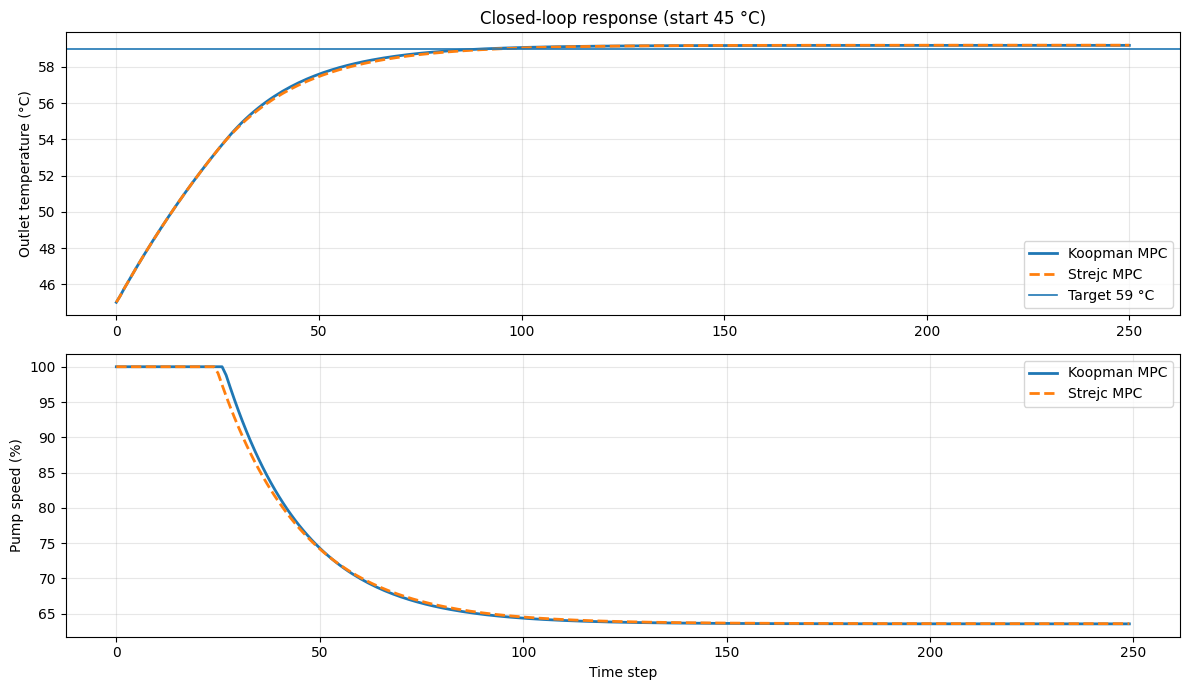

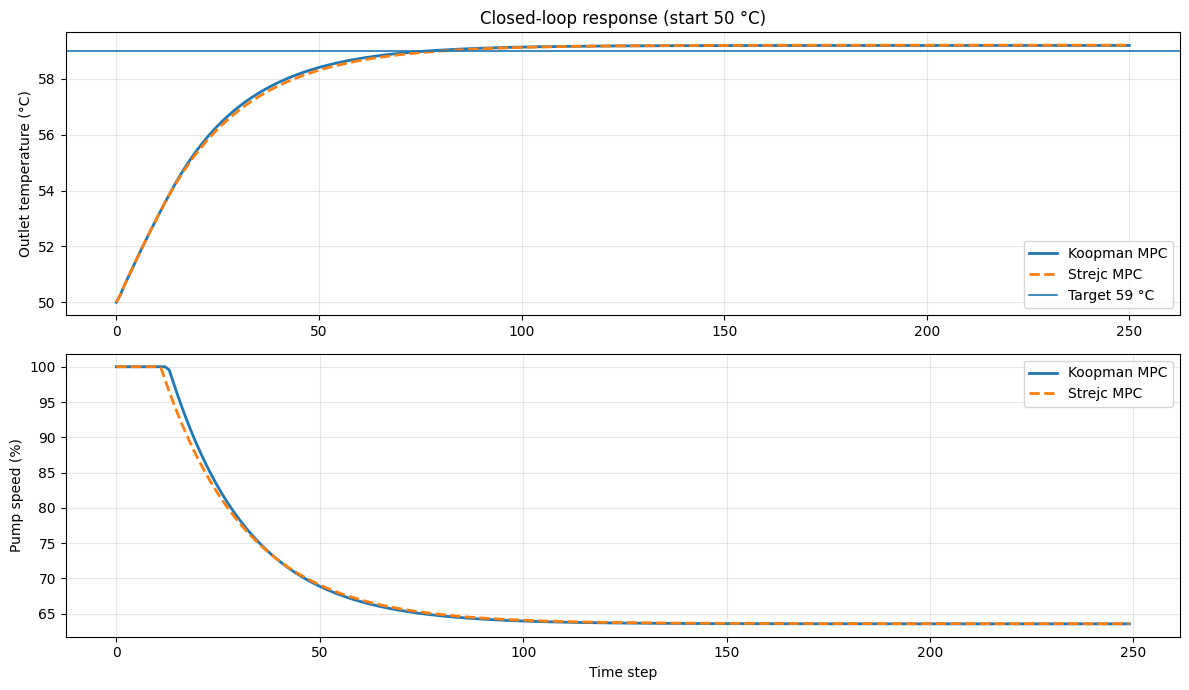

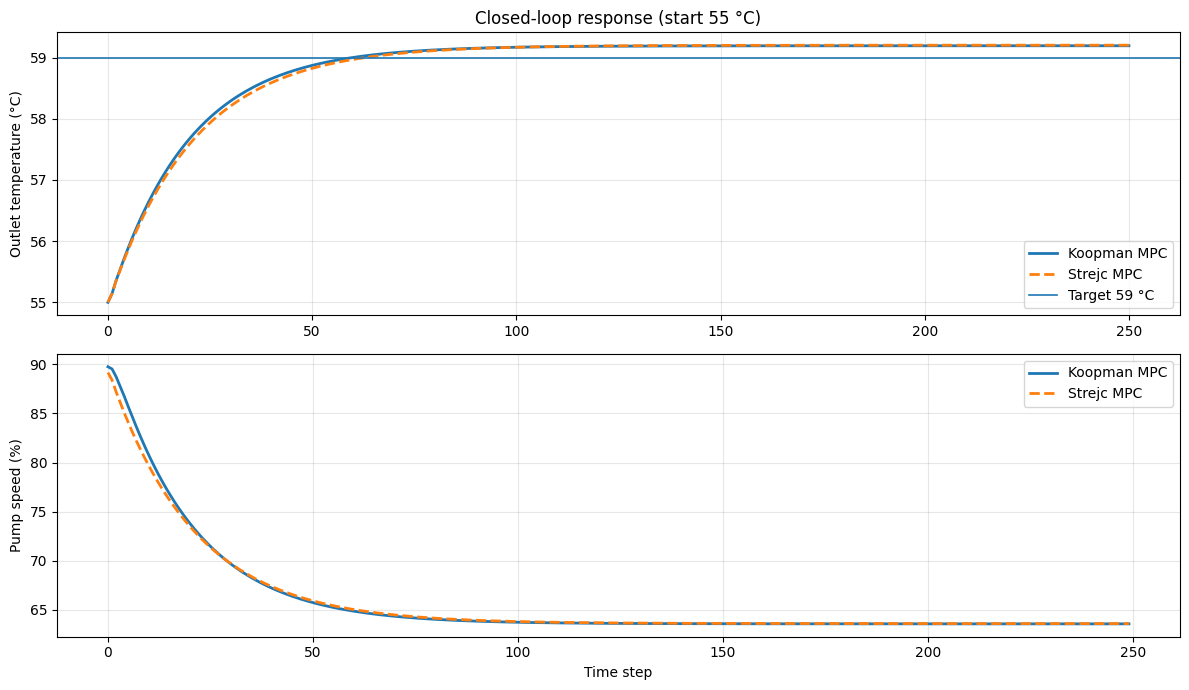

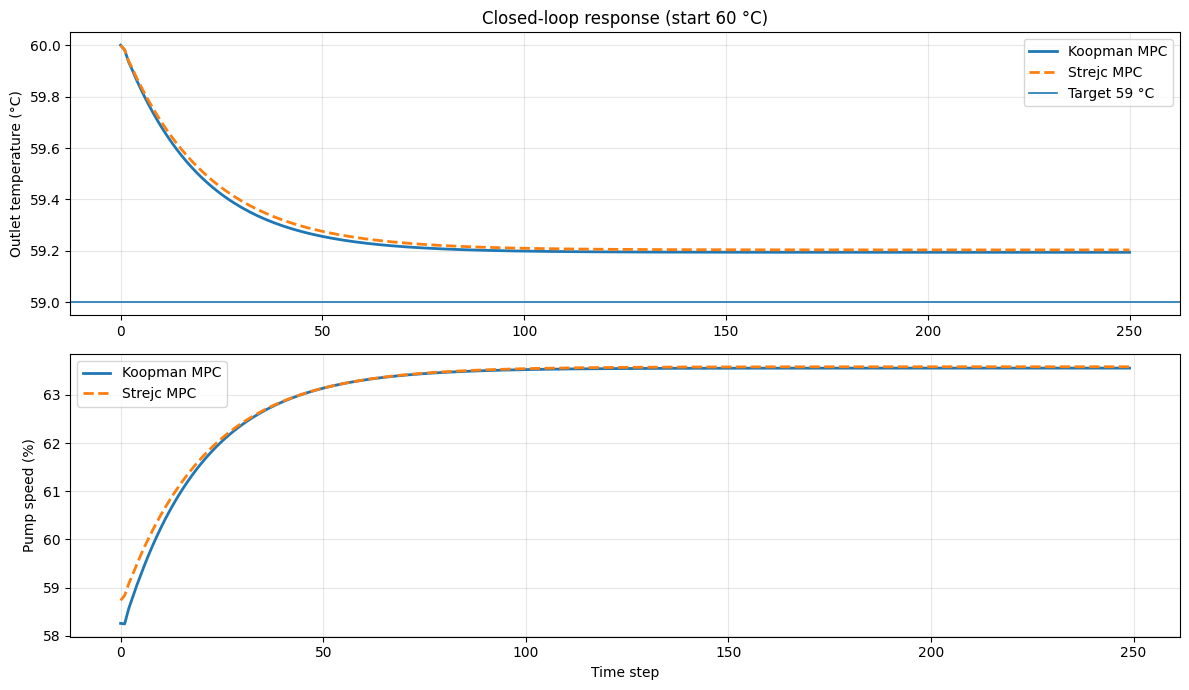

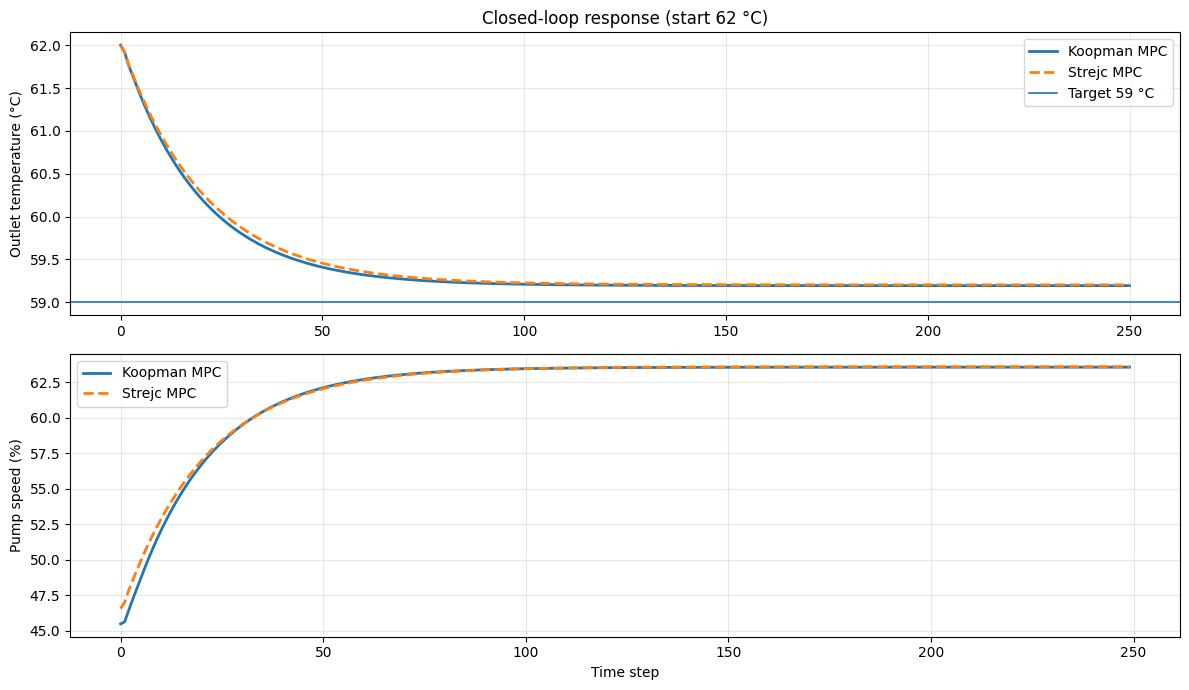

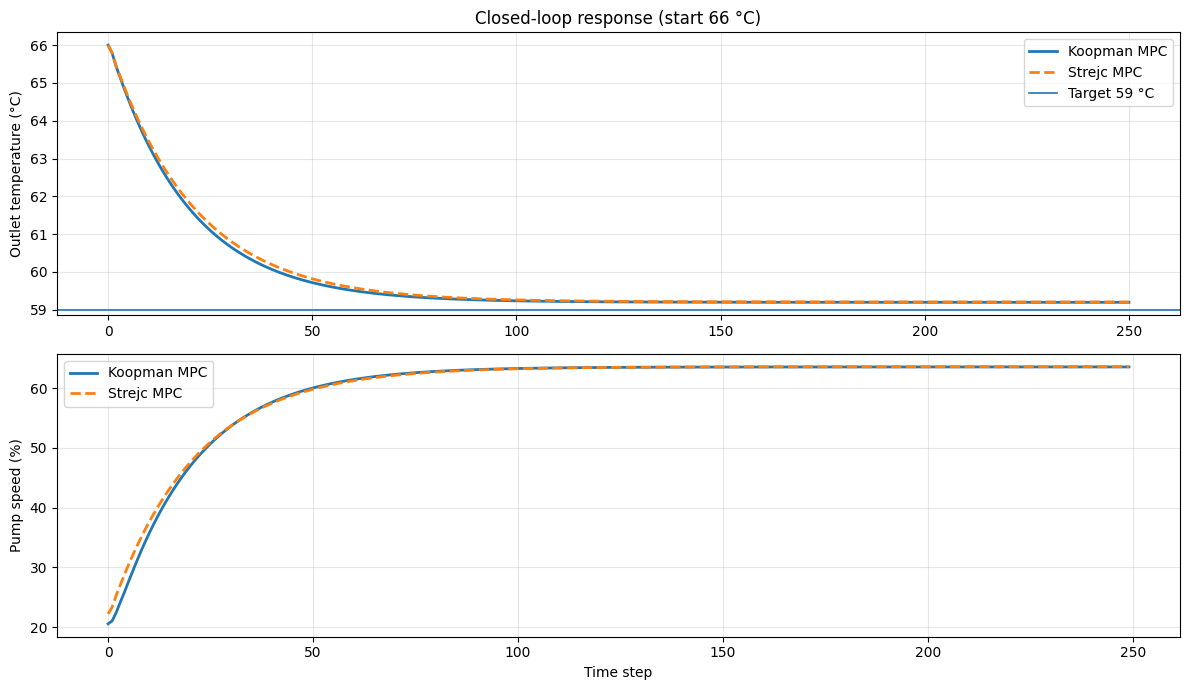

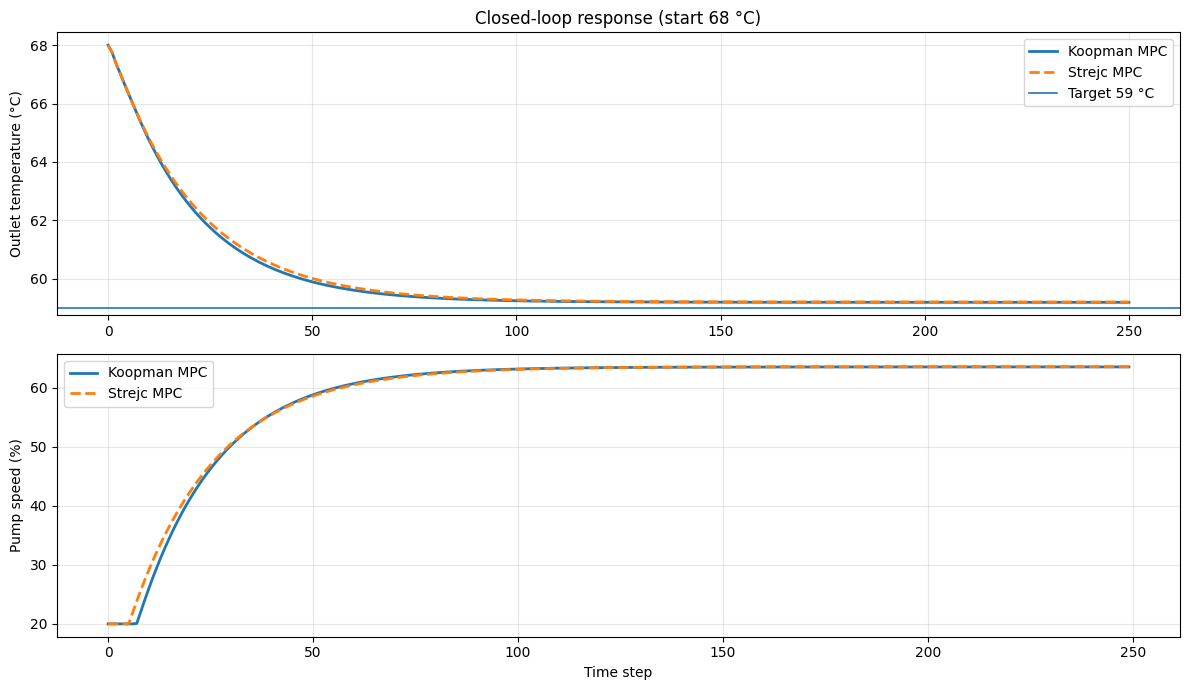


Summary:
   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.353518  3.363404  368.393036  374.409025  72319.103671  70910.543668
1  50  1.946784  1.963750  213.144323  219.276827  37080.507782  35675.962870
2  55  0.803488  0.822716  102.312552  106.666018   8633.890178   7960.201843
3  60  0.301020  0.313057   64.910827   68.111083   1374.788590   1310.926731
4  62  0.676126  0.698223  105.236026  110.960392   6457.735611   6022.880339
5  66  1.484445  1.526825  186.095053  196.659011  30234.830237  28083.925605
6  68  1.940904  1.975293  232.152872  242.957292  46039.310785  43747.035970


In [12]:
#s kalmanom 
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
DATA_DIR = os.path.join(SEM2025_DIR, "data")
MODEL_PATH = os.path.join(DATA_DIR, "modelC.pth")
ARX_THETA_PATH = os.path.join(DATA_DIR, "theta_abs.npy")

temps = [45, 50, 55, 60, 62, 66, 68]
sim_length = 250

USE_CACHED_ARX = True
FORCE_RETRAIN_ARX = False

# ============================================================
# MATLAB-LIKE MPC SETTINGS
# ============================================================

# Koopman
N_koop = 20
Qy_koop = 10.0
Qu_koop = 1.0
QKF_koop = 0.5
RKF_koop = 0.1

# Strejc
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0
QKF_strejc = 0.5
RKF_strejc = 0.1

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA
# ============================================================
train_data = loadmat(os.path.join(DATA_DIR, "train_data.mat"))
test_data  = loadmat(os.path.join(DATA_DIR, "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest  = test_data["Ytest"].reshape(-1)
Utest  = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(DATA_DIR, "scaler.pkl"))
scalerU = joblib.load(os.path.join(DATA_DIR, "scalerU.pkl"))

# ------------------------------------------------------------
# Use MATLAB-like scaling from stored data
# ------------------------------------------------------------
y_mean = float(np.mean(Ytrain))
y_std  = float(np.std(Ytrain))
u_mean = float(np.mean(Utrain))
u_std  = float(np.std(Utrain))

print("MATLAB-like scaling:")
print("y_mean =", y_mean)
print("y_std  =", y_std)
print("u_mean =", u_mean)
print("u_std  =", u_std)

# scaled bounds
umin_scaled = (20.0 - u_mean) / u_std
umax_scaled = (100.0 - u_mean) / u_std
ymin_scaled = (0.0 - y_mean) / y_std
ymax_scaled = (70.0 - y_mean) / y_std

print("umin_scaled =", umin_scaled)
print("umax_scaled =", umax_scaled)
print("ymin_scaled =", ymin_scaled)
print("ymax_scaled =", ymax_scaled)

# ============================================================
# ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X, T = [], []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k-1], U[k], U[k-1], 1.0])
        T.append(Y[k+1])
    return np.array(X), np.array(T)

def train_or_load_arx_theta(Ytrain, Utrain, theta_path, use_cache=True, force_retrain=False):
    if use_cache and (not force_retrain) and os.path.exists(theta_path):
        theta = np.load(theta_path)
        print(f"Loaded cached ARX theta from: {theta_path}")
        return theta

    print("Training ARX theta once...")
    Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
    theta, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)

    if use_cache:
        np.save(theta_path, theta)
        print(f"Saved ARX theta to: {theta_path}")

    return theta

theta_abs = train_or_load_arx_theta(
    Ytrain, Utrain, ARX_THETA_PATH,
    use_cache=USE_CACHED_ARX,
    force_retrain=FORCE_RETRAIN_ARX
)

print("theta_abs =", theta_abs)
print("ARX bias  =", theta_abs[-1])

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        reg = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(reg @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

# ============================================================
# LOAD KOOPMAN MODEL
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)

# ============================================================
# STREJC MODEL - MATLAB STYLE
# ============================================================
A_strejc = np.array([[0.98540172]], dtype=float)
B_strejc = np.array([[0.01640409]], dtype=float)
C_strejc = np.array([[1.0]], dtype=float)

# ============================================================
# SCALING HELPERS
# ============================================================
def y_phys_to_scaled(y_phys):
    return (float(y_phys) - y_mean) / y_std

def y_scaled_to_phys(y_scaled):
    return float(y_scaled * y_std + y_mean)

def u_phys_to_scaled(u_phys):
    return (float(u_phys) - u_mean) / u_std

def u_scaled_to_phys(u_scaled):
    return float(u_scaled * u_std + u_mean)

# ============================================================
# KOOPMAN ENCODE/DECODE
# ============================================================
def encode_y_to_x_from_scaled_y(y_scaled):
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    return encode_y_to_x_from_scaled_y(y_scaled)

def decode_x_to_y_scaled(x_latent):
    return float((C_koop @ x_latent).item())

def decode_x_to_y_phys(x_latent):
    return y_scaled_to_phys(decode_x_to_y_scaled(x_latent))

# ============================================================
# MPC BUILDERS - MATLAB STYLE
# objective = sum(Qy*yk^2 + Qu*uk^2)
# ============================================================
def build_mpc_solver(A, B, C, N, Qy, Qu, umin, umax, ymin, ymax):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))
    x0_param = cp.Parameter((nx, 1))

    constraints = [X[:, [0]] == x0_param]
    objective = 0.0

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        constraints += [U[:, [k]] >= umin]
        constraints += [U[:, [k]] <= umax]
        constraints += [yk >= ymin]
        constraints += [yk <= ymax]

        objective += Qy * cp.sum_squares(yk)
        objective += Qu * cp.sum_squares(U[:, [k]])

    prob = cp.Problem(cp.Minimize(objective), constraints)

    def solver(x0):
        x0_param.value = x0.reshape(-1, 1)
        prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        if U.value is None:
            return 0.0
        return float(U.value[0, 0])

    return solver

koop_solver = build_mpc_solver(
    A_koop, B_koop, C_koop,
    N_koop, Qy_koop, Qu_koop,
    umin_scaled, umax_scaled, ymin_scaled, ymax_scaled
)

strejc_solver = build_mpc_solver(
    A_strejc, B_strejc, C_strejc,
    N_strejc, Qy_strejc, Qu_strejc,
    umin_scaled, umax_scaled, ymin_scaled, ymax_scaled
)

# ============================================================
# KALMAN FILTER STEP
# ============================================================
def kf_step(A, C, x_est, P, y_meas_scaled, Q_KF, R_KF):
    x_pred = A @ x_est
    P_pred = A @ P @ A.T + Q_KF

    S = C @ P_pred @ C.T + R_KF
    K = P_pred @ C.T @ np.linalg.inv(S)

    x_est_new = x_pred + K @ (np.array([[y_meas_scaled]]) - C @ x_pred)
    P_new = (np.eye(A.shape[0]) - K @ C) @ P_pred
    P_new = 0.5 * (P_new + P_new.T)

    return x_est_new, P_new

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"\nSimulating T0 = {T0} °C")

    # --------------------------------------------------------
    # Koopman controller init like MATLAB
    # --------------------------------------------------------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_mean)

    y0_scaled = y_phys_to_scaled(T0)
    x_est_k = encode_y_to_x_from_scaled_y(y0_scaled)
    P_k = np.eye(A_koop.shape[0])

    y_store_k = [T0]
    u_store_k = []
    yhat_store_k = []

    for _ in range(sim_length):
        y_now = y_store_k[-1]
        y_scaled_now = y_phys_to_scaled(y_now)

        x_est_k, P_k = kf_step(
            A_koop, C_koop,
            x_est_k, P_k,
            y_scaled_now,
            QKF_koop * np.eye(A_koop.shape[0]),
            np.array([[RKF_koop]])
        )

        u_scaled = koop_solver(x_est_k)
        u_cmd = u_scaled_to_phys(u_scaled)
        u_cmd = float(np.clip(u_cmd, 0, 100))

        yhat_store_k.append(decode_x_to_y_phys(x_est_k))

        y_next = plant_k.step(u_cmd)

        y_store_k.append(y_next)
        u_store_k.append(u_cmd)

    # --------------------------------------------------------
    # Strejc controller init like MATLAB
    # --------------------------------------------------------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_mean)

    y0_scaled = y_phys_to_scaled(T0)
    x_est_s = np.array([[y0_scaled]])
    P_s = np.array([[1.0]])

    y_store_s = [T0]
    u_store_s = []

    for _ in range(sim_length):
        y_now = y_store_s[-1]
        y_scaled_now = y_phys_to_scaled(y_now)

        x_est_s, P_s = kf_step(
            A_strejc, C_strejc,
            x_est_s, P_s,
            y_scaled_now,
            np.array([[QKF_strejc]]),
            np.array([[RKF_strejc]])
        )

        u_scaled = strejc_solver(x_est_s)
        u_cmd = u_scaled_to_phys(u_scaled)
        u_cmd = float(np.clip(u_cmd, 0, 100))

        y_next = plant_s.step(u_cmd)

        y_store_s.append(y_next)
        u_store_s.append(u_cmd)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]
    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(59.0, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - 59.0
    e_s = res["y_strejc"][:-1] - 59.0

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_mean
    du_s = res["u_strejc"] - u_mean

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print("\nSummary:")
print(summary_df)